<a href="https://colab.research.google.com/github/ShauryaPrakashVerma/Python_for_AI/blob/main/Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### What is Pandas

Pandas is a fast, powerful, flexible and easy to use open source data analysis and manipulation tool,
built on top of the Python programming language.

https://pandas.pydata.org/about/index.html

# Pandas Series
- in a table each column is a series.
- Its like a column in table. it is a 1D array holding data of any type.

##Importing Pandas

In [ ]:
import pandas as pd

# since pandas is built on top of pandas , it is a good idea to import numpy as well
import numpy as np

### Series from list

In [ ]:
# string
country = ['india','nepal','bhutan','srilanka']
pd.Series(country)

# series always has two things --> index, value of type(object)
# in pandas most of the time string is referred as objects

,0
0,india
1,nepal
2,bhutan
3,srilanka


In [ ]:
# integers
runs = [1,2,3,4,5,7,8,9]
pd.Series(runs)

,0
0,1
1,2
2,3
3,4
4,5
5,7
6,8
7,9


In [ ]:
# custom index
marks = [2,30,23,40]
subjects = ['maths','english','science','hindi']

# we want the subjects as index to the marks
pd.Series(marks, index = subjects)

,0
maths,2
english,30
science,23
hindi,40


In [ ]:
# setting a name

marks = pd.Series(marks, index = subjects, name = "Shaurya's marks")

marks

,Shaurya's marks
maths,2
english,30
science,23
hindi,40


### Creating series from dict

In [ ]:
marks = {
    'maths':67,
    'english': 54,
    'hindi': 19
}

marks_series = pd.Series(marks, name = "Shaurya's marks")
marks_series

# here the keys become the indexes while the values become the actual values

,Shaurya's marks
maths,67
english,54
hindi,19


##Series attributes

In [ ]:
# size
marks_series
marks_series.size

3

In [ ]:
# dtype
marks_series.dtype

dtype('int64')

In [ ]:
# name
marks_series.name

"Shaurya's marks"

In [ ]:
# is_unique
marks_series.is_unique

True

In [ ]:
# index
marks_series.index        # returns an index object

Index(['maths', 'english', 'hindi'], dtype='object')

In [ ]:
# values
marks_series.values

array([67, 54, 19])

## Series using read.csv

In [ ]:
# with one col

# reading data from the file and converting it into series
# data is imported but it is not a series, it is a dataframe
# type(pd.read_csv('/content/subs.csv'))

# to make it a series we have to make a small change


subs = pd.read_csv('/content/subs.csv').squeeze()
print(type(subs))
print(subs)

<class 'pandas.core.series.Series'>
0       48
1       57
2       40
3       43
4       44
      ... 
360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64


In [ ]:
# runs = pd.read_csv('/content/kohli_ipl.csv').squeeze()
# .squeeze wont work on a data with multiple columns, to make it work we have to specify Index_col as in the following example:

runs = pd.read_csv('/content/kohli_ipl.csv',index_col="match_no").squeeze()
print(type(runs))
print(runs)

<class 'pandas.core.series.Series'>
match_no
1       1
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64


In [ ]:
movie = pd.read_csv('/content/bollywood.csv',index_col="movie").squeeze()
print(type(movie))
print(movie)

<class 'pandas.core.series.Series'>
movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Hum Tumhare Hain Sanam                    Shah Rukh Khan
Aankhen (2002 film)                     Amitabh Bachchan
Saathiya (film)                             Vivek Oberoi
Company (film)                                Ajay Devgn
Awara Paagal Deewana                        Akshay Kumar
Name: lead, Length: 1500, dtype: object


### Series methods

In [ ]:
# head --> gives top 5 rows by default only for previweing data
print(subs.head())

# we can control the no of rows shown in preview
print(subs.head(3))

0    48
1    57
2    40
3    43
4    44
Name: Subscribers gained, dtype: int64
0    48
1    57
2    40
Name: Subscribers gained, dtype: int64


In [ ]:
# tail --> gives last 5 rows by default only for previewing data
print(subs.tail())

# no of rows can be controlled
print(subs.tail(3))

360    231
361    226
362    155
363    144
364    172
Name: Subscribers gained, dtype: int64
362    155
363    144
364    172
Name: Subscribers gained, dtype: int64


In [ ]:
# sample --> randomly shows 1 row from the dataset

# useful when there is some bias in the dataset

print(movie.sample())


print("\n")
# can control the no of rows in the sample
print(movie.sample(5))

movie
Fanaa (2006 film)    Aamir Khan
Name: lead, dtype: object


movie
Koyelaanchal                     Kannan Arunachalam
Kuku Mathur Ki Jhand Ho Gayi        Siddharth Gupta
Shaadi Se Pehle                      Akshaye Khanna
Guddu Rangeela                         Arshad Warsi
Saankal                         Tanima Bhattacharya
Name: lead, dtype: object


In [ ]:
# value_counts ---> frequency of items in the dataset

# for.eg if we want to find out the no of movies of individual actors
print(movie.value_counts())


# printing for any specific actor
print("\n")
abc = movie.value_counts()
print(abc["Anupam Kher"])

lead
Akshay Kumar         48
Amitabh Bachchan     45
Ajay Devgn           38
Salman Khan          31
Sanjay Dutt          26
                     ..
Seema Azmi            1
Akanksha Puri         1
Charanpreet Insan     1
Jaideep Ahlawat       1
Monali Thakur         1
Name: count, Length: 566, dtype: int64


13


In [ ]:
# sort values --> doesnt change the original dataset, if we want we can change the original dataset

print(runs.sort_values())    # in ascending order
print("\n")
print(runs.sort_values(ascending=False))
print("\n")
print(runs.sort_values(ascending=False).head())
print("\n")
print(runs.sort_values(ascending=False).head(1))
print("\n")
print(runs.sort_values(ascending=False).head(1).values)
print("\n")
print(runs.sort_values(ascending=False).head(1).values[0])    # extracting highest runs of vyrat kohli by method chaining

match_no
8        0
87       0
93       0
91       0
206      0
      ... 
164    100
120    100
123    108
126    109
128    113
Name: runs, Length: 215, dtype: int64


match_no
128    113
126    109
123    108
120    100
164    100
      ... 
93       0
130      0
206      0
207      0
211      0
Name: runs, Length: 215, dtype: int64


match_no
128    113
126    109
123    108
120    100
164    100
Name: runs, dtype: int64


match_no
128    113
Name: runs, dtype: int64


[113]


113


### - try to get into the habit of reassigning variables (e.g., df = df.sort_values()) rather than using inplace=True. It’s much more "Pythonic" and helps avoid these tricky SettingWithCopy warnings and errors!

In [ ]:
# making changes in the original dataset by sort_values function
# changing the value of inplace attribute to True
runs.sort_values(inplace = True)

ValueError: This Series is a view of some other array, to sort in-place you must create a copy

In [ ]:
# sort_index  ---> sorts according to the index
print(movie.sort_index())
print("\n")
print(movie.sort_index(ascending=False))

movie
1920 (film)                   Rajniesh Duggall
1920: London                     Sharman Joshi
1920: The Evil Returns             Vicky Ahuja
1971 (2007 film)                Manoj Bajpayee
2 States (2014 film)              Arjun Kapoor
                                   ...        
Zindagi 50-50                      Veena Malik
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi Tere Naam           Mithun Chakraborty
Zokkomon                       Darsheel Safary
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Name: lead, Length: 1500, dtype: object


movie
Zor Lagaa Ke...Haiya!            Meghan Jadhav
Zokkomon                       Darsheel Safary
Zindagi Tere Naam           Mithun Chakraborty
Zindagi Na Milegi Dobara        Hrithik Roshan
Zindagi 50-50                      Veena Malik
                                   ...        
2 States (2014 film)              Arjun Kapoor
1971 (2007 film)                Manoj Bajpayee
1920: The Evil Returns             Vicky Ahuja
1920: 

## Series Maths methods

In [ ]:
# count

# dont confuse with size , size also counts the missing values, count doesn't count the missing values
runs.count()

np.int64(215)

In [ ]:
# sum ---> adds all the items
subs.sum()

# subs.product()   ---> product of all itemms

np.int64(49510)

In [ ]:
# mean
print(subs.mean())

# median
print(runs.median())

# mode
# print the actor who has made most movies
print(movie.mode())  # here 0 is the index , to get rid of it use the next statement
print(movie.mode()[0])

# std --> standard deviation
print(subs.std())

# var --> variance
print(subs.var())

135.64383561643837
24.0
0    Akshay Kumar
Name: lead, dtype: object
Akshay Kumar
62.67502303725269
3928.1585127201556


In [ ]:
# min/ max
print(subs.max())
print(subs.min())

396
33


In [ ]:
# describe --> gives a summary
print(subs.describe())

count    365.000000
mean     135.643836
std       62.675023
min       33.000000
25%       88.000000
50%      123.000000
75%      177.000000
max      396.000000
Name: Subscribers gained, dtype: float64


## Series indexing

In [ ]:
# integer indexing
x = pd.Series([12,13,14,15,16,17,18])
print(x[1])   # positive indexing works, but the negative indexing doesn't work
print(x[-1])

13


KeyError: -1

In [ ]:
movie[1]

/tmp/ipykernel_1470/101055391.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  movie[1]


'Vicky Ahuja'

In [ ]:
movie.iloc[1]   # IN THIS DATSET movie name is the index, but pandas internally maintains an index by default , ehich i have used for accessing the value

'Vicky Ahuja'

In [ ]:
# wierd behaviour flagged
print(movie[-1])

print(movie.iloc[-1])


Akshay Kumar
Akshay Kumar


/tmp/ipykernel_1470/2309222837.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(movie[-1])


### Slicing

In [ ]:
# slicing
print(runs[5:15])

match_no
6      9
7     34
8      0
9     21
10     3
11    10
12    38
13     3
14    11
15    50
Name: runs, dtype: int64


In [ ]:
# negative indexing --> same as python behaviour
print(runs[-5::])

match_no
211     0
212    20
213    73
214    25
215     7
Name: runs, dtype: int64


In [ ]:
# fancy indexing also works here
print(runs[[1,3,6,7]])

match_no
1     1
3    13
6     9
7    34
Name: runs, dtype: int64


In [ ]:
# indexing with labels --> fancy indexing
movie['Zokkomon']

'Darsheel Safary'

## Editing Series

In [ ]:
# using series
marks_series[1] = 100
print(marks_series)

maths       67
english    100
hindi       19
Name: Shaurya's marks, dtype: int64


/tmp/ipykernel_1470/1069262044.py:2: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  marks_series[1] = 100


In [ ]:
# what if the index doesnt exist
marks_series['evs'] = 100

In [ ]:
print(marks_series)

maths       67
english    100
hindi       19
evs        100
Name: Shaurya's marks, dtype: int64


In [ ]:
# slicing
marks_series[0:2] = [100,100]
marks_series

,Shaurya's marks
maths,100
english,100
hindi,19
evs,100


In [ ]:
# fancy indexing
marks_series[[0,1,2]] = [0,0,0]
marks_series

/tmp/ipykernel_1470/623723689.py:2: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  marks_series[[0,1,2]] = [0,0,0]


,Shaurya's marks
maths,0
english,0
hindi,0
evs,100


In [ ]:
# using index label
movie['2 States (2014 film)'] = 'Alia Bhatt'
movie

,lead
movie,
Uri: The Surgical Strike,Vicky Kaushal
Battalion 609,Vicky Ahuja
The Accidental Prime Minister (film),Anupam Kher
Why Cheat India,Emraan Hashmi
Evening Shadows,Mona Ambegaonkar
...,...
Hum Tumhare Hain Sanam,Shah Rukh Khan
Aankhen (2002 film),Amitabh Bachchan
Saathiya (film),Vivek Oberoi


### Series with Python Functionalities

In [ ]:
# len/type/dir/sorted/max/min
print(len(subs))
print(type(subs))
print(dir(subs))
print(sorted(subs))
print(min(subs))
print(max(subs))

365
<class 'pandas.core.series.Series'>
['T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__bool__', '__class__', '__column_consortium_standard__', '__contains__', '__copy__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__float__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__int__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__nonzero__', '__or__', '__pandas_priority__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce

In [ ]:
# type conversion
list(marks_series)

[0, 0, 0, 100]

In [ ]:
dict(marks_series)

{'maths': np.int64(0),
 'english': np.int64(0),
 'hindi': np.int64(0),
 'evs': np.int64(100)}

In [ ]:
# membership operator

'2 States (2014 film)' in movie

True

In [ ]:
'Alia Bhatt' in movie.values

True

In [ ]:
# looping
for i in movie.index:
  print(i)

Uri: The Surgical Strike
Battalion 609
The Accidental Prime Minister (film)
Why Cheat India
Evening Shadows
Soni (film)
Fraud Saiyaan
Bombairiya
Manikarnika: The Queen of Jhansi
Thackeray (film)
Amavas
Gully Boy
Hum Chaar
Total Dhamaal
Sonchiriya
Badla (2019 film)
Mard Ko Dard Nahi Hota
Hamid (film)
Photograph (film)
Risknamaa
Mere Pyare Prime Minister
22 Yards
Kesari (film)
Notebook (2019 film)
Junglee (2019 film)
Gone Kesh
Albert Pinto Ko Gussa Kyun Aata Hai?
The Tashkent Files
Kalank
Setters (film)
Student of the Year 2
PM Narendra Modi
De De Pyaar De
India's Most Wanted (film)
Yeh Hai India
Khamoshi (2019 film)
Kabir Singh
Article 15 (film)
One Day: Justice Delivered
Hume Tumse Pyaar Kitna
Super 30 (film)
Family of Thakurganj
Batla House
Jhootha Kahin Ka
Judgementall Hai Kya
Chicken Curry Law
Arjun Patiala
Jabariya Jodi
Pranaam
The Sky Is Pink
Mission Mangal
Saaho
Dream Girl (2019 film)
Section 375
The Zoya Factor (film)
Pal Pal Dil Ke Paas
Prassthanam
P Se Pyaar F Se Faraar
Ghost 

In [ ]:
# Arithmetic Operators(Broadcasting)
100 + marks_series

,Shaurya's marks
maths,100
english,100
hindi,100
evs,200


In [ ]:
# Relational Operators

runs >= 50

,runs
match_no,
1,False
2,False
3,False
4,False
5,False
...,...
211,False
212,False
213,True


In [ ]:
print(runs[runs>50])

match_no
34      58
41      71
44      56
45      67
52      70
57      57
68      73
71      51
73      58
74      65
80      57
81      93
82      99
85      56
97      67
99      73
103     51
104     62
110     82
116     75
117     79
119     80
120    100
122     52
123    108
126    109
127     75
128    113
129     54
131     54
132     62
134     64
137     55
141     58
144     57
145     92
148     68
152     70
160     84
162     67
164    100
175     72
178     90
188     72
197     51
198     53
209     58
213     73
Name: runs, dtype: int64


In [ ]:
# Find no of 50's and 100's scored by kohli
runs[runs >= 50].size

50

In [ ]:
# find number of ducks
runs[runs == 0].size

9

In [ ]:
# find actors who have done more than 20 movies
num_movie = movie.value_counts()
num_movie[num_movie > 20]

,count
lead,
Akshay Kumar,48
Amitabh Bachchan,45
Ajay Devgn,38
Salman Khan,31
Sanjay Dutt,26
Shah Rukh Khan,22
Emraan Hashmi,21


### Plotting Graphs on Series

<Axes: >

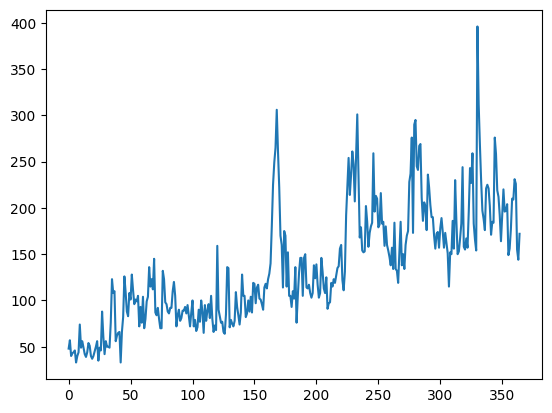

In [ ]:
subs.plot()

<Axes: ylabel='count'>

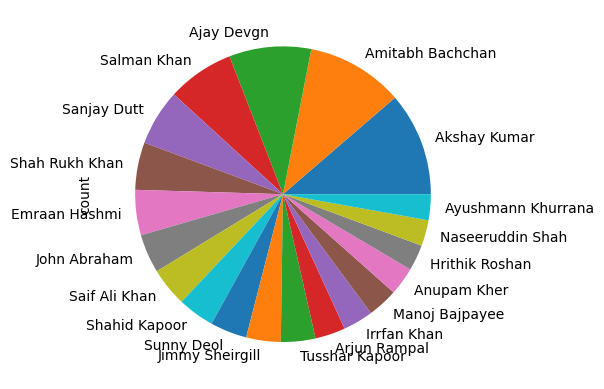

In [ ]:
movie.value_counts().head(20).plot(kind='pie')

### Some Important Series Methods

In [ ]:
# astype
# between
# clip
# drop_duplicates
# isnull
# dropna
# fillna
# isin
# apply
# copy

In [ ]:
# astype
import sys

sys.getsizeof(runs.astype('int16'))

2182

In [ ]:
# between
print(runs[runs.between(51,99)])
print(runs[runs.between(51,99)].size)

match_no
34     58
41     71
44     56
45     67
52     70
57     57
68     73
71     51
73     58
74     65
80     57
81     93
82     99
85     56
97     67
99     73
103    51
104    62
110    82
116    75
117    79
119    80
122    52
127    75
129    54
131    54
132    62
134    64
137    55
141    58
144    57
145    92
148    68
152    70
160    84
162    67
175    72
178    90
188    72
197    51
198    53
209    58
213    73
Name: runs, dtype: int64
43


In [ ]:
# clip
print(subs.clip(100, 200))

0      100
1      100
2      100
3      100
4      100
      ... 
360    200
361    200
362    155
363    144
364    172
Name: Subscribers gained, Length: 365, dtype: int64


In [ ]:
temp = pd.Series([1,2,1,3,4,1,2,3,4,5,6])
print(temp)

0     1
1     2
2     1
3     3
4     4
5     1
6     2
7     3
8     4
9     5
10    6
dtype: int64


In [ ]:
# drop_duplicates
print(temp.drop_duplicates())   # by default keeps the first occurence
print(temp.drop_duplicates(keep="last"))   # keeps the last occurences

0     1
1     2
3     3
4     4
9     5
10    6
dtype: int64
5     1
6     2
7     3
8     4
9     5
10    6
dtype: int64


In [ ]:
print(movie.drop_duplicates())    # keeps only the first movie of each actor

movie
Uri: The Surgical Strike                   Vicky Kaushal
Battalion 609                                Vicky Ahuja
The Accidental Prime Minister (film)         Anupam Kher
Why Cheat India                            Emraan Hashmi
Evening Shadows                         Mona Ambegaonkar
                                              ...       
Sssshhh...                              Tanishaa Mukerji
Rules: Pyaar Ka Superhit Formula                  Tanuja
Right Here Right Now (film)                        Ankit
Talaash: The Hunt Begins...                Rakhee Gulzar
The Pink Mirror                          Edwin Fernandes
Name: lead, Length: 566, dtype: object


In [ ]:
temp[temp.duplicated()]     # tells which values are duplicated
temp.duplicated().sum()

np.int64(5)

In [ ]:
runs.duplicated().sum()

np.int64(137)

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
temp = pd.Series([1,2,3,np.nan,5,6,np.nan,8,np.nan,10])
print(temp)

0     1.0
1     2.0
2     3.0
3     NaN
4     5.0
5     6.0
6     NaN
7     8.0
8     NaN
9    10.0
dtype: float64


In [ ]:
temp.size

10

In [ ]:
temp.count()   # does not count missing values

np.int64(7)

In [ ]:
# isnull
print(temp.isnull())

0    False
1    False
2    False
3     True
4    False
5    False
6     True
7    False
8     True
9    False
dtype: bool


In [ ]:
# how to handle missing values
# - either remove them
# - or fill them

temp.isnull().sum()

np.int64(3)

In [ ]:
# drop(remove) missing values
print(temp.dropna())

0     1.0
1     2.0
2     3.0
4     5.0
5     6.0
7     8.0
9    10.0
dtype: float64


In [ ]:
# fillna()   --> fill the missing values
print(temp.fillna(0))   # --> replace missing values with 0

0     1.0
1     2.0
2     3.0
3     0.0
4     5.0
5     6.0
6     0.0
7     8.0
8     0.0
9    10.0
dtype: float64


In [ ]:
# isin
runs[((runs == 49) | (runs == 99))]
# if we want to check multiple conditions we need not create long checks
# we use isin()

runs[runs.isin([49,99])]

,runs
match_no,
82,99
86,49


In [ ]:
# apply
# if someone says that they want only the first name of the actor in upper case

movie.apply(lambda x:x.split()[0].upper())

,lead
movie,
Uri: The Surgical Strike,VICKY
Battalion 609,VICKY
The Accidental Prime Minister (film),ANUPAM
Why Cheat India,EMRAAN
Evening Shadows,MONA
...,...
Hum Tumhare Hain Sanam,SHAH
Aankhen (2002 film),AMITABH
Saathiya (film),VIVEK


In [ ]:
subs.apply(lambda x:'good day' if x > subs.mean() else 'bad day')

,Subscribers gained
0,bad day
1,bad day
2,bad day
3,bad day
4,bad day
...,...
360,good day
361,good day
362,good day
363,good day


In [ ]:
# copy
new = runs.head()
new

,runs
match_no,
1,1
2,23
3,13
4,12
5,1


In [ ]:
new[1] = 2

In [ ]:
new

,runs
match_no,
1,2
2,23
3,13
4,12
5,1


In [ ]:
runs

,runs
match_no,
1,2
2,23
3,13
4,12
5,1
...,...
211,0
212,20
213,73


In [ ]:
# original data is changed when changed in .head or.tail
# they pass a view of the data
# so any changes are also made in the original data
# to avoid this we make a copy of the original data

In [ ]:
new = runs.head().copy()
new[1] = 100

In [ ]:
print(new)
print(runs)

# on creating a copy of the original data , the copy is modified and the main data is still preserved.

match_no
1    100
2     23
3     13
4     12
5      1
Name: runs, dtype: int64
match_no
1       2
2      23
3      13
4      12
5       1
       ..
211     0
212    20
213    73
214    25
215     7
Name: runs, Length: 215, dtype: int64


# Dataframe
- basically a table of data is a datframe.

### Creating a datframe

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
# using lists
student_data = [
    [100,80,10],
    [90,70,7],
    [120,100,14],
    [80,50,2]
]

pd.DataFrame(student_data, columns=['iq','marks','package'])

,iq,marks,package
0,100,80,10
1,90,70,7
2,120,100,14
3,80,50,2


In [ ]:
# using dictionary

student_dict = {
    'iq':[100,90,120,80],
    'marks': [80,70,100,50],
    'package': [10,7,14,2]
}
students = pd.DataFrame(student_dict)
students

,iq,marks,package
0,100,80,10
1,90,70,7
2,120,100,14
3,80,50,2


In [ ]:
movies = pd.read_csv('movies.csv')
movies

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1624,Tera Mera Saath Rahen,tt0301250,https://upload.wikimedia.org/wikipedia/en/2/2b...,https://en.wikipedia.org/wiki/Tera_Mera_Saath_...,Tera Mera Saath Rahen,Tera Mera Saath Rahen,0,2001,148,Drama,4.9,278,Raj Dixit lives with his younger brother Rahu...,A man is torn between his handicapped brother ...,NaN,Ajay Devgn|Sonali Bendre|Namrata Shirodkar|Pre...,NaN,7 November 2001 (India)
1625,Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
1626,Sabse Bada Sukh,tt0069204,NaN,https://en.wikipedia.org/wiki/Sabse_Bada_Sukh,Sabse Bada Sukh,Sabse Bada Sukh,0,2018,\N,Comedy|Drama,6.1,13,Village born Lalloo re-locates to Bombay and ...,Village born Lalloo re-locates to Bombay and ...,NaN,Vijay Arora|Asrani|Rajni Bala|Kumud Damle|Utpa...,NaN,NaN
1627,Daaka,tt10833860,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Daaka,Daaka,Daaka,0,2019,136,Action,7.4,38,Shinda tries robbing a bank so he can be wealt...,Shinda tries robbing a bank so he can be wealt...,NaN,Gippy Grewal|Zareen Khan|,NaN,1 November 2019 (USA)


In [ ]:
ipl = pd.read_csv('ipl-matches.csv')
ipl

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri


### DataFrame Attributes and Methods

In [ ]:
# shape
movies.shape

(1629, 18)

In [ ]:
ipl.shape

(950, 20)

In [ ]:
# dtypes
movies.dtypes
# return is a series where index is the column name and the datatype is the value.
# in pandas lingo object refers to a string

,0
title_x,object
imdb_id,object
poster_path,object
wiki_link,object
title_y,object
original_title,object
is_adult,int64
year_of_release,int64
runtime,object
genres,object


In [ ]:
# index
movies.index

RangeIndex(start=0, stop=1629, step=1)

In [ ]:
# columns
movies.columns

Index(['title_x', 'imdb_id', 'poster_path', 'wiki_link', 'title_y',
       'original_title', 'is_adult', 'year_of_release', 'runtime', 'genres',
       'imdb_rating', 'imdb_votes', 'story', 'summary', 'tagline', 'actors',
       'wins_nominations', 'release_date'],
      dtype='object')

In [ ]:
ipl.columns

Index(['ID', 'City', 'Date', 'Season', 'MatchNumber', 'Team1', 'Team2',
       'Venue', 'TossWinner', 'TossDecision', 'SuperOver', 'WinningTeam',
       'WonBy', 'Margin', 'method', 'Player_of_Match', 'Team1Players',
       'Team2Players', 'Umpire1', 'Umpire2'],
      dtype='object')

In [ ]:
# values

ipl.values
# returns 2D numpy array

array([[1312200, 'Ahmedabad', '2022-05-29', ...,
        "['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pandya', 'DA Miller', 'R Tewatia', 'Rashid Khan', 'R Sai Kishore', 'LH Ferguson', 'Yash Dayal', 'Mohammed Shami']",
        'CB Gaffaney', 'Nitin Menon'],
       [1312199, 'Ahmedabad', '2022-05-27', ...,
        "['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D Padikkal', 'SO Hetmyer', 'R Parag', 'R Ashwin', 'TA Boult', 'YS Chahal', 'M Prasidh Krishna', 'OC McCoy']",
        'CB Gaffaney', 'Nitin Menon'],
       [1312198, 'Kolkata', '2022-05-25', ...,
        "['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda', 'MP Stoinis', 'E Lewis', 'KH Pandya', 'PVD Chameera', 'Mohsin Khan', 'Avesh Khan', 'Ravi Bishnoi']",
        'J Madanagopal', 'MA Gough'],
       ...,
       [335984, 'Delhi', '2008-04-19', ...,
        "['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif', 'DS Lehmann', 'RA Jadeja', 'M Rawat', 'D Salunkhe', 'SK Warne', 'SK Trivedi', 'MM Patel']",
        'Aleem Dar', 'GA Pratapkumar'],
    

In [ ]:
# head and tail
movies.head()

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)


In [ ]:
# tail
ipl.tail

<bound method NDFrame.tail of           ID        City        Date   Season  MatchNumber  \
0    1312200   Ahmedabad  2022-05-29     2022        Final   
1    1312199   Ahmedabad  2022-05-27     2022  Qualifier 2   
2    1312198     Kolkata  2022-05-25     2022   Eliminator   
3    1312197     Kolkata  2022-05-24     2022  Qualifier 1   
4    1304116      Mumbai  2022-05-22     2022           70   
..       ...         ...         ...      ...          ...   
945   335986     Kolkata  2008-04-20  2007/08            4   
946   335985      Mumbai  2008-04-20  2007/08            5   
947   335984       Delhi  2008-04-19  2007/08            3   
948   335983  Chandigarh  2008-04-19  2007/08            2   
949   335982   Bangalore  2008-04-18  2007/08            1   

                           Team1                        Team2  \
0               Rajasthan Royals               Gujarat Titans   
1    Royal Challengers Bangalore             Rajasthan Royals   
2    Royal Challengers Bangalore         Lucknow Super Giants   
3               Rajasthan Royals               Gujarat Titans   
4            Sunrisers Hyderabad                 Punjab Kings   
..                           ...                          ...   
945        Kolkata Knight Riders              Deccan Chargers   
946               Mumbai Indians  Royal Challengers Bangalore   
947             Delhi Daredevils             Rajasthan Royals   
948              Kings XI Punjab          Chennai Super Kings   
949  Royal Challengers Bangalore        Kolkata Knight Riders   

                                          Venue                   TossWinner  \
0              Narendra Modi Stadium, Ahmedabad             Rajasthan Royals   
1              Narendra Modi Stadium, Ahmedabad             Rajasthan Royals   
2                         Eden Gardens, Kolkata         Lucknow Super Giants   
3                         Eden Gardens, Kolkata               Gujarat Titans   
4                      Wankhede Stadium, Mumbai          Sunrisers Hyderabad   
..                                          ...                          ...   
945                                Eden Gardens              Deccan Chargers   
946                            Wankhede Stadium               Mumbai Indians   
947                            Feroz Shah Kotla             Rajasthan Royals   
948  Punjab Cricket Association Stadium, Mohali          Chennai Super Kings   
949                       M Chinnaswamy Stadium  Royal Challengers Bangalore   

    TossDecision SuperOver                  WinningTeam    WonBy  Margin  \
0            bat         N               Gujarat Titans  Wickets     7.0   
1          field         N             Rajasthan Royals  Wickets     7.0   
2          field         N  Royal Challengers Bangalore     Runs    14.0   
3          field         N               Gujarat Titans  Wickets     7.0   
4            bat         N                 Punjab Kings  Wickets     5.0   
..           ...       ...                          ...      ...     ...   
945          bat         N        Kolkata Knight Riders  Wickets     5.0   
946          bat         N  Royal Challengers Bangalore  Wickets     5.0   
947          bat         N             Delhi Daredevils  Wickets     9.0   
948          bat         N          Chennai Super Kings     Runs    33.0   
949        field         N        Kolkata Knight Riders     Runs   140.0   

    method Player_of_Match                                       Team1Players  \
0      NaN       HH Pandya  ['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...   
1      NaN      JC Buttler  ['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...   
2      NaN      RM Patidar  ['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...   
3      NaN       DA Miller  ['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...   
4      NaN   Harpreet Brar  ['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...   
..     ...             ...                                                ...   
945

In [ ]:
# sample
ipl.sample(5)

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
885,392188,Cape Town,2009-04-22,2009,8,Royal Challengers Bangalore,Deccan Chargers,Newlands,Deccan Chargers,bat,N,Deccan Chargers,Runs,24.0,NaN,AC Gilchrist,"['JD Ryder', 'RV Uthappa', 'JH Kallis', 'KP Pi...","['AC Gilchrist', 'HH Gibbs', 'VVS Laxman', 'RG...",M Erasmus,AM Saheba
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
222,1178407,Chandigarh,2019-04-16,2019,32,Kings XI Punjab,Rajasthan Royals,Punjab Cricket Association IS Bindra Stadium,Rajasthan Royals,field,N,Kings XI Punjab,Runs,12.0,NaN,R Ashwin,"['KL Rahul', 'CH Gayle', 'MA Agarwal', 'DA Mil...","['RA Tripathi', 'JC Buttler', 'SV Samson', 'AM...",AK Chaudhary,VA Kulkarni
937,335994,Mumbai,2008-04-27,2007/08,14,Mumbai Indians,Deccan Chargers,Dr DY Patil Sports Academy,Deccan Chargers,field,N,Deccan Chargers,Wickets,10.0,NaN,AC Gilchrist,"['L Ronchi', 'ST Jayasuriya', 'AM Rahane', 'RV...","['AC Gilchrist', 'VVS Laxman', 'A Symonds', 'R...",Asad Rauf,SL Shastri
673,548334,Mumbai,2012-04-22,2012,28,Mumbai Indians,Kings XI Punjab,Wankhede Stadium,Mumbai Indians,bat,N,Kings XI Punjab,Wickets,6.0,NaN,SE Marsh,"['JEC Franklin', 'SR Tendulkar', 'RG Sharma', ...","['N Saini', 'Mandeep Singh', 'SE Marsh', 'DJ H...",S Ravi,RJ Tucker


In [ ]:
# info
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1629 entries, 0 to 1628
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title_x           1629 non-null   object 
 1   imdb_id           1629 non-null   object 
 2   poster_path       1526 non-null   object 
 3   wiki_link         1629 non-null   object 
 4   title_y           1629 non-null   object 
 5   original_title    1629 non-null   object 
 6   is_adult          1629 non-null   int64  
 7   year_of_release   1629 non-null   int64  
 8   runtime           1629 non-null   object 
 9   genres            1629 non-null   object 
 10  imdb_rating       1629 non-null   float64
 11  imdb_votes        1629 non-null   int64  
 12  story             1609 non-null   object 
 13  summary           1629 non-null   object 
 14  tagline           557 non-null    object 
 15  actors            1624 non-null   object 
 16  wins_nominations  707 non-null    object 


In [ ]:
# describe    --> gives a summary of the data
movies.describe()

,is_adult,year_of_release,imdb_rating,imdb_votes
count,1629.0,1629.000000,1629.000000,1629.000000
mean,0.0,2010.263966,5.557459,5384.263352
std,0.0,5.381542,1.567609,14552.103231
min,0.0,2001.000000,0.000000,0.000000
25%,0.0,2005.000000,4.400000,233.000000
50%,0.0,2011.000000,5.600000,1000.000000
75%,0.0,2015.000000,6.800000,4287.000000
max,0.0,2019.000000,9.400000,310481.000000


In [ ]:
# isnull  --> in data frmae it checks for null values
movies.isnull().sum()

,0
title_x,0
imdb_id,0
poster_path,103
wiki_link,0
title_y,0
original_title,0
is_adult,0
year_of_release,0
runtime,0
genres,0


In [ ]:
# duplicated
ipl.duplicated().sum()

np.int64(0)

In [ ]:
# reaname --> renames the column name in the dataframe
students.rename(columns={'marks':'percent', 'ppackage':'lpa'})   # not permanent changes
students.rename(columns={'marks':'percent', 'ppackage':'lpa'},inplace = True)  # permanent changes (ie in the original data)

### Math Methods

In [ ]:
# sum


# columwise and rowise applies to all maths methods
students.sum()     #columnwise sum
students.sum(axis=1)    #rowise sum

,0
0,190
1,167
2,234
3,132


In [ ]:
students.mean()   # column wise
students.mean(axis=1)  # rowise

,0
0,63.333333
1,55.666667
2,78.000000
3,44.000000


In [ ]:
students.min()    # columnwise

,0
iq,80
percent,50
package,2


In [ ]:
students.max()

,0
iq,120
percent,100
package,14


In [ ]:
# variance
students.var()

,0
iq,291.666667
percent,433.333333
package,25.583333


In [ ]:
# standard deviation
students.std()

,0
iq,17.078251
percent,20.816660
package,5.057997


## Selecting a column from the dataframe

In [ ]:
# single cols
movies['actors']

# table is a dataframe while the column is a series
# here it is proved
print(type(movies['actors']))

<class 'pandas.core.series.Series'>


In [ ]:
# multiple columns

movies[['title_x','imdb_id','title_y']]    # now this is a dataframe, ordeer in the list matters for order in the dataframe

,title_x,imdb_id,title_y
0,Uri: The Surgical Strike,tt8291224,Uri: The Surgical Strike
1,Battalion 609,tt9472208,Battalion 609
2,The Accidental Prime Minister (film),tt6986710,The Accidental Prime Minister
3,Why Cheat India,tt8108208,Why Cheat India
4,Evening Shadows,tt6028796,Evening Shadows
...,...,...,...
1624,Tera Mera Saath Rahen,tt0301250,Tera Mera Saath Rahen
1625,Yeh Zindagi Ka Safar,tt0298607,Yeh Zindagi Ka Safar
1626,Sabse Bada Sukh,tt0069204,Sabse Bada Sukh
1627,Daaka,tt10833860,Daaka


### Selecting rows from a DataFrame

- **iloc** - searches using index positions
- **loc** - searches using index labels

In [ ]:
student_dict = {
    'name':['nitish','ankit','rupesh','rishabh','amit','ankita'],
    'iq':[100,90,120,80,0,0],
    'marks':[80,70,100,50,0,0],
    'package':[10,7,14,2,0,0]
}
students = pd.DataFrame(student_dict)
students.set_index('name',inplace=True)
students

,iq,marks,package
name,,,
nitish,100,80,10
ankit,90,70,7
rupesh,120,100,14
rishabh,80,50,2
amit,0,0,0
ankita,0,0,0


In [ ]:
movies.iloc[0]    # returns a series since a single row is being fetched

,0
title_x,Uri: The Surgical Strike
imdb_id,tt8291224
poster_path,https://upload.wikimedia.org/wikipedia/en/thum...
wiki_link,https://en.wikipedia.org/wiki/Uri:_The_Surgica...
title_y,Uri: The Surgical Strike
original_title,Uri: The Surgical Strike
is_adult,0
year_of_release,2019
runtime,138
genres,Action|Drama|War


In [ ]:
# multiple rows
movies.iloc[0:5]    # return a database

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)


In [ ]:
# fancy indexing
movies.iloc[[0,4,5]]

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)
5,Soni (film),tt6078866,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Soni_(film),Soni,Soni,0,2018,97,Drama,7.2,1595,Soni a young policewoman in Delhi and her su...,While fighting crimes against women in Delhi ...,NaN,Geetika Vidya Ohlyan|Saloni Batra|Vikas Shukla...,3 wins & 5 nominations,18 January 2019 (USA)


In [ ]:
# loc
students.loc['nitish']

,nitish
iq,100
marks,80
package,10


In [ ]:
# multiple items usinf loc
students.loc['nitish':'rishabh']

,iq,marks,package
name,,,
nitish,100,80,10
ankit,90,70,7
rupesh,120,100,14
rishabh,80,50,2


In [ ]:
students.loc[['nitish','ankita','rupesh']]

# iloc will also work here even though the index is not an iteger, bc pandas maintain a default index by itself.
students.iloc[0]

,nitish
iq,100
marks,80
package,10


## iloc vs loc
- in iloc range last value is excluded
- in loc range last value is included

### Selecting both rows and cols

In [ ]:
movies.iloc[0:3,0:3]

,title_x,imdb_id,poster_path
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...
1,Battalion 609,tt9472208,NaN
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...


In [ ]:
movies.loc[0:2,'title_x':'poster_path']

,title_x,imdb_id,poster_path
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...
1,Battalion 609,tt9472208,NaN
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...


### Filtering a DataFrame

In [ ]:
ipl


,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri


In [ ]:
new = ipl[ipl['MatchNumber'] == 'Final']
new[['Season','WinningTeam']]

,Season,WinningTeam
0,2022,Gujarat Titans
74,2021,Chennai Super Kings
134,2020/21,Mumbai Indians
194,2019,Mumbai Indians
254,2018,Chennai Super Kings
314,2017,Mumbai Indians
373,2016,Sunrisers Hyderabad
433,2015,Mumbai Indians
492,2014,Kolkata Knight Riders
552,2013,Mumbai Indians


In [ ]:
ipl.loc['WinningTeam']    # error bcz 'WinningTeam' is not actually a label for any row, its a column name

KeyError: 'WinningTeam'

In [ ]:
# how many super over finishes have occured
super_over = ipl[ipl['SuperOver'] == 'Y']
super_over.shape[0]

14

In [ ]:
# how many matches has csk won in kolkata
csk = ipl[ipl['City'] == 'Kolkata']
csk[csk['WinningTeam'] == 'Chennai Super Kings']

ipl[(ipl['City'] == 'Kolkata') & (ipl['WinningTeam'] == 'Chennai Super Kings')]

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
224,1178404,Kolkata,2019-04-14,2019,29,Kolkata Knight Riders,Chennai Super Kings,Eden Gardens,Chennai Super Kings,field,N,Chennai Super Kings,Wickets,5.0,NaN,Imran Tahir,"['CA Lynn', 'SP Narine', 'N Rana', 'RV Uthappa...","['SR Watson', 'F du Plessis', 'SK Raina', 'AT ...",CK Nandan,RJ Tucker
602,598022,Kolkata,2013-04-20,2013,26,Kolkata Knight Riders,Chennai Super Kings,Eden Gardens,Kolkata Knight Riders,bat,N,Chennai Super Kings,Wickets,4.0,NaN,RA Jadeja,"['G Gambhir', 'YK Pathan', 'JH Kallis', 'EJG M...","['MEK Hussey', 'R Ashwin', 'M Vijay', 'SK Rain...",Asad Rauf,AK Chaudhary
641,548368,Kolkata,2012-05-14,2012,63,Kolkata Knight Riders,Chennai Super Kings,Eden Gardens,Chennai Super Kings,field,N,Chennai Super Kings,Wickets,5.0,NaN,MEK Hussey,"['G Gambhir', 'BB McCullum', 'JH Kallis', 'MK ...","['MEK Hussey', 'M Vijay', 'SK Raina', 'F du Pl...",JD Cloete,SJA Taufel
827,419113,Kolkata,2010-03-16,2009/10,8,Kolkata Knight Riders,Chennai Super Kings,Eden Gardens,Chennai Super Kings,bat,N,Chennai Super Kings,Runs,55.0,NaN,MS Dhoni,"['BJ Hodge', 'MK Tiwary', 'SC Ganguly', 'WP Sa...","['M Vijay', 'ML Hayden', 'SK Raina', 'S Badrin...",HDPK Dharmasena,AM Saheba
908,336025,Kolkata,2008-05-18,2007/08,41,Kolkata Knight Riders,Chennai Super Kings,Eden Gardens,Kolkata Knight Riders,bat,N,Chennai Super Kings,Runs,3.0,D/L,M Ntini,"['Salman Butt', 'Mohammad Hafeez', 'SC Ganguly...","['PA Patel', 'SP Fleming', 'S Vidyut', 'SK Rai...",Asad Rauf,K Hariharan


In [ ]:
# toss winner is match winner in percentage
ipl

((ipl[ipl['TossWinner'] == ipl['WinningTeam']].shape[0])/(ipl.shape[0]))*100

51.473684210526315

In [ ]:
# movies with rating higher than 8 and votes > 10000
movies
movies[(movies['imdb_rating'] > 8) & (movies['imdb_votes'] > 1000)]

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
11,Gully Boy,tt2395469,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Gully_Boy,Gully Boy,Gully Boy,0,2019,153,Drama|Music,8.2,22440,"Gully Boy is a film about a 22-year-old boy ""M...",A coming-of-age story based on the lives of st...,Apna Time Aayega!,Ranveer Singh|Alia Bhatt|Siddhant Chaturvedi|V...,6 wins & 3 nominations,14 February 2019 (USA)
37,Article 15 (film),tt10324144,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Article_15_(film),Article 15,Article 15,0,2019,130,Crime|Drama,8.3,13417,In the rural heartlands of India an upright p...,In the rural heartlands of India an upright p...,Farq Bahut Kar Liya| Ab Farq Laayenge.,Ayushmann Khurrana|Nassar|Manoj Pahwa|Kumud Mi...,1 win,28 June 2019 (USA)
40,Super 30 (film),tt7485048,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Super_30_(film),Super 30,Super 30,0,2019,154,Biography|Drama,8.2,13972,Anand Kumar a Mathematics genius from a modes...,Based on life of Patna-based mathematician Ana...,Inspired by the Life of Anand Kumar & His Stud...,Hrithik Roshan|Mrunal Thakur|Nandish Singh|Vir...,NaN,12 July 2019 (USA)
53,Section 375,tt8144834,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Section_375,Section 375,Section 375,0,2019,124,Crime|Drama,8.4,1841,A celebrated Bollywood director Rohan Khurana ...,A celebrated Bollywood director Rohan Khurana ...,NaN,Akshaye Khanna|Richa Chadha|Meera Chopra|Rahul...,NaN,13 September 2019 (USA)
58,Ghost (2019 film),tt9378950,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Ghost_(2019_film),Ghost,Ghost,0,2019,130,Horror|Thriller,8.7,1379,The story of the film follows Karan Khanna a ...,The story of the film follows Karan Khanna a ...,NaN,Sanaya Irani|Shivam Bhaargava|Vikram Bhatt|Ame...,NaN,18 October 2019 (India)
59,Bala (2019 film),tt9420648,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Bala_(2019_film),Bala,Bala,0,2019,133,Comedy,8.2,1369,Focuses on a young man Gaurav Rawat aka Bala (...,It tells the story of a man who is balding pre...,NaN,Ayushmann Khurrana|Bhumi Pednekar|Yami Gautam|...,NaN,7 November 2019 (USA)
62,Saand Ki Aankh,tt8108206,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Saand_Ki_Aankh,Saand Ki Aankh,Saand Ki Aankh,0,2019,146,Biography|Drama,8.9,1902,Both over the age of 60 Chandro Tomar and Pra...,Both over the age of 60 Chandro Tomar and Pra...,NaN,Taapsee Pannu|Bhumi Pednekar|Prakash Jha|Viine...,1 nomination,25 October 2019 (USA)
64,Ujda Chaman,tt11046300,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Ujda_Chaman,Ujda Chaman,Ujda Chaman,0,2019,120,Comedy,8.1,1440,Ujda Chaman is about a 30 -year-old bachelor C...,Ujda Chaman is about a 30 -year-old bachelor C...,NaN,Sunny Singh Nijjar|Maanvi Gagroo|Saurabh Shukl...,NaN,1 November 2019 (USA)
84,Mukkabaaz,tt7180544,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Mukkabaaz,The Brawler,Mukkabaaz,0,2017,154,Action|Drama|Sport,8.1,5434,A boxer (Shravan) belonging to upper cast tra...,A boxer struggles to make his mark in the boxi...,NaN,Viineet Kumar|Jimmy Sheirgill|Zoya Hussain|Rav...,3 wins & 6 nominations,12 January 2018 (USA)


In [ ]:
# Action movies with rating higher than 7.5
movies
movies[(movies['genres'].str.contains('Action')) & (movies['imdb_rating'] > 7.5)]

# mask1 = movies['genres'].str.split('|').apply(lambda x:'Action' in x)

# another way
mask1 = movies['genres'].str.contains('Action')
mask2 = movies['imdb_rating'] > 7.5
movies[mask1 & mask2]

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
41,Family of Thakurganj,tt8897986,https://upload.wikimedia.org/wikipedia/en/9/99...,https://en.wikipedia.org/wiki/Family_of_Thakur...,Family of Thakurganj,Family of Thakurganj,0,2019,127,Action|Drama,9.4,895,The film is based on small town of North India...,The film is based on small town of North India...,NaN,Jimmy Sheirgill|Mahie Gill|Nandish Singh|Prana...,NaN,19 July 2019 (India)
84,Mukkabaaz,tt7180544,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Mukkabaaz,The Brawler,Mukkabaaz,0,2017,154,Action|Drama|Sport,8.1,5434,A boxer (Shravan) belonging to upper cast tra...,A boxer struggles to make his mark in the boxi...,NaN,Viineet Kumar|Jimmy Sheirgill|Zoya Hussain|Rav...,3 wins & 6 nominations,12 January 2018 (USA)
106,Raazi,tt7098658,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Raazi,Raazi,Raazi,0,2018,138,Action|Drama|Thriller,7.8,20289,Hidayat Khan is the son of an Indian freedom f...,A Kashmiri woman agrees to marry a Pakistani a...,An incredible true story,Alia Bhatt|Vicky Kaushal|Rajit Kapoor|Shishir ...,21 wins & 26 nominations,11 May 2018 (USA)
110,Parmanu: The Story of Pokhran,tt6826438,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Parmanu:_The_Sto...,Parmanu: The Story of Pokhran,Parmanu: The Story of Pokhran,0,2018,129,Action|Drama|History,7.7,18292,Captain Ashwat Raina's efforts to turn India i...,Ashwat Raina and his teammates arrive in Pokhr...,1998| India: one secret operation| six Indians...,John Abraham|Boman Irani|Diana Penty|Anuja Sat...,NaN,25 May 2018 (USA)
112,Bhavesh Joshi Superhero,tt6129302,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Bhavesh_Joshi_Su...,Bhavesh Joshi Superhero,Bhavesh Joshi Superhero,0,2018,154,Action|Drama,7.6,4928,Bhavesh Joshi Superhero is an action film abou...,The origin story of Bhavesh Joshi an Indian s...,This year| justice will have a new name.,Harshvardhan Kapoor|Priyanshu Painyuli|Ashish ...,2 nominations,1 June 2018 (USA)
169,The Ghazi Attack,tt6299040,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Ghazi_Attack...,The Ghazi Attack,The Ghazi Attack,0,2017,116,Action|Thriller|War,7.6,10332,In 1971 amid rising tensions between India an...,A Pakistani submarine Ghazi plans to secretly...,The war you did not know about,Rana Daggubati|Kay Kay Menon|Atul Kulkarni|Om ...,1 win & 7 nominations,17 February 2017 (USA)
219,Raag Desh (film),tt6080746,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Raagdesh,Raag Desh,Raag Desh,0,2017,135,Action|Drama|History,8.3,341,A period film based on the historic 1945 India...,A period film based on the historic 1945 India...,NaN,Kunal Kapoor|Amit Sadh|Mohit Marwah|Kenneth De...,NaN,28 July 2017 (India)
258,Irudhi Suttru,tt5310090,https://upload.wikimedia.org/wikipedia/en/f/fe...,https://en.wikipedia.org/wiki/Saala_Khadoos,Saala Khadoos,Saala Khadoos,0,2016,109,Action|Drama|Sport,7.6,10507,An under-fire boxing coach Prabhu is transfer...,The story of a former boxer who quits boxing f...,NaN,Madhavan|Ritika Singh|Mumtaz Sorcar|Nassar|Rad...,9 wins & 2 nominations,29 January 2016 (USA)
280,Laal Rang,tt5600714,NaN,https://en.wikipedia.org/wiki/Laal_Rang,Laal Rang,Laal Rang,0,2016,147,Action|Crime|Drama,8.0,3741,The friendship of two men is tested when thing...,The frie

In [ ]:
def track_record(team1, team2):
  # Filter for matches where team1 played against team2, regardless of who was Team1 or Team2
  t1_vs_t2_filter = (ipl['Team1'] == team1) & (ipl['Team2'] == team2)
  t2_vs_t1_filter = (ipl['Team1'] == team2) & (ipl['Team2'] == team1)

  total_matches = ipl[t1_vs_t2_filter | t2_vs_t1_filter]

  # Count wins for each team
  team1_wins = total_matches[total_matches['WinningTeam'] == team1].shape[0]
  team2_wins = total_matches[total_matches['WinningTeam'] == team2].shape[0]

  print(f"Total matches played between {team1} and {team2}: {total_matches.shape[0]}")
  print(f"{team1} wins: {team1_wins}")
  print(f"{team2} wins: {team2_wins}")

# Example usage:
track_record('Mumbai Indians','Chennai Super Kings')


Total matches played between Mumbai Indians and Chennai Super Kings: 34
Mumbai Indians wins: 20
Chennai Super Kings wins: 14


### Adding new cols

In [ ]:
# completely new
movies['Country'] = 'India'
movies.head()

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date,Country
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA),India
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India),India
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA),India
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA),India
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India),India


In [ ]:
# from existing ones
movies.dropna(inplace=True)
#  removes any rows from the movies DataFrame that contain at least one missing (NaN) value. The inplace=True argument means that the operation modifies the movies DataFrame directly, without returning a new DataFrame.

In [ ]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 298 entries, 11 to 1623
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title_x           298 non-null    object 
 1   imdb_id           298 non-null    object 
 2   poster_path       298 non-null    object 
 3   wiki_link         298 non-null    object 
 4   title_y           298 non-null    object 
 5   original_title    298 non-null    object 
 6   is_adult          298 non-null    int64  
 7   year_of_release   298 non-null    int64  
 8   runtime           298 non-null    object 
 9   genres            298 non-null    object 
 10  imdb_rating       298 non-null    float64
 11  imdb_votes        298 non-null    int64  
 12  story             298 non-null    object 
 13  summary           298 non-null    object 
 14  tagline           298 non-null    object 
 15  actors            298 non-null    object 
 16  wins_nominations  298 non-null    object 
 17  

In [ ]:
movies['lead actor'] = movies['actors'].str.split('|').apply(lambda x:x[0])
movies.head()

### Important DataFrame Functions

In [ ]:
# astype --> changes the datatype of a column in the dataset
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               950 non-null    int64  
 1   City             899 non-null    object 
 2   Date             950 non-null    object 
 3   Season           950 non-null    object 
 4   MatchNumber      950 non-null    object 
 5   Team1            950 non-null    object 
 6   Team2            950 non-null    object 
 7   Venue            950 non-null    object 
 8   TossWinner       950 non-null    object 
 9   TossDecision     950 non-null    object 
 10  SuperOver        946 non-null    object 
 11  WinningTeam      946 non-null    object 
 12  WonBy            950 non-null    object 
 13  Margin           932 non-null    float64
 14  method           19 non-null     object 
 15  Player_of_Match  946 non-null    object 
 16  Team1Players     950 non-null    object 
 17  Team2Players    

In [ ]:
# changing the datatype of ID column in ipl dataset
ipl['ID'] = ipl['ID'].astype('int32')

In [ ]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   ID               950 non-null    int32   
 1   City             899 non-null    object  
 2   Date             950 non-null    object  
 3   Season           950 non-null    object  
 4   MatchNumber      950 non-null    object  
 5   Team1            950 non-null    category
 6   Team2            950 non-null    category
 7   Venue            950 non-null    object  
 8   TossWinner       950 non-null    object  
 9   TossDecision     950 non-null    object  
 10  SuperOver        946 non-null    object  
 11  WinningTeam      946 non-null    object  
 12  WonBy            950 non-null    object  
 13  Margin           932 non-null    float64 
 14  method           19 non-null     object  
 15  Player_of_Match  946 non-null    object  
 16  Team1Players     950 non-null    object  
 1

In [ ]:
# ipl['Season'] = ipl['Season'].astype('category')
ipl['Team1'] = ipl['Team1'].astype('category')
ipl['Team2'] = ipl['Team2'].astype('category')

# pandas has a data type called category. nothing changes visually but space occupied is reduced.

# ipl['Team1'].astype('category')  simply this would not make the changes permanent
# so we reassign it to ipl['Team1'] = ipl['Team1'].astype('category') so that the changes are permanent


In [ ]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   ID               950 non-null    int32   
 1   City             899 non-null    object  
 2   Date             950 non-null    object  
 3   Season           950 non-null    object  
 4   MatchNumber      950 non-null    object  
 5   Team1            950 non-null    category
 6   Team2            950 non-null    category
 7   Venue            950 non-null    object  
 8   TossWinner       950 non-null    object  
 9   TossDecision     950 non-null    object  
 10  SuperOver        946 non-null    object  
 11  WinningTeam      946 non-null    object  
 12  WonBy            950 non-null    object  
 13  Margin           932 non-null    float64 
 14  method           19 non-null     object  
 15  Player_of_Match  946 non-null    object  
 16  Team1Players     950 non-null    object  
 1

# Important Methods

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
# value_counts (series and dataframe)
# rows frequency is counted
marks = pd.DataFrame( [
    [100,80,10],
    [90,70,7],
    [120,100,14],
    [80,50,2]
], columns=['iq','marks','package'])

marks.value_counts()

,,,count
iq,marks,package,
80,50,2,1
90,70,7,1
100,80,10,1
120,100,14,1


In [ ]:
ipl = pd.read_csv("ipl-matches.csv")
ipl

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,SuperOver,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,N,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,N,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,N,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,N,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,N,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
945,335986,Kolkata,2008-04-20,2007/08,4,Kolkata Knight Riders,Deccan Chargers,Eden Gardens,Deccan Chargers,bat,N,Kolkata Knight Riders,Wickets,5.0,NaN,DJ Hussey,"['WP Saha', 'BB McCullum', 'RT Ponting', 'SC G...","['AC Gilchrist', 'Y Venugopal Rao', 'VVS Laxma...",BF Bowden,K Hariharan
946,335985,Mumbai,2008-04-20,2007/08,5,Mumbai Indians,Royal Challengers Bangalore,Wankhede Stadium,Mumbai Indians,bat,N,Royal Challengers Bangalore,Wickets,5.0,NaN,MV Boucher,"['L Ronchi', 'ST Jayasuriya', 'DJ Thornely', '...","['S Chanderpaul', 'R Dravid', 'LRPL Taylor', '...",SJ Davis,DJ Harper
947,335984,Delhi,2008-04-19,2007/08,3,Delhi Daredevils,Rajasthan Royals,Feroz Shah Kotla,Rajasthan Royals,bat,N,Delhi Daredevils,Wickets,9.0,NaN,MF Maharoof,"['G Gambhir', 'V Sehwag', 'S Dhawan', 'MK Tiwa...","['T Kohli', 'YK Pathan', 'SR Watson', 'M Kaif'...",Aleem Dar,GA Pratapkumar
948,335983,Chandigarh,2008-04-19,2007/08,2,Kings XI Punjab,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,bat,N,Chennai Super Kings,Runs,33.0,NaN,MEK Hussey,"['K Goel', 'JR Hopes', 'KC Sangakkara', 'Yuvra...","['PA Patel', 'ML Hayden', 'MEK Hussey', 'MS Dh...",MR Benson,SL Shastri


In [ ]:
# find the player who has won most MOTM match award in final and semi finals matches.

# to use any str function we have to first use the .str


ipl[~ipl["MatchNumber"].str.isdigit()]['Player_of_Match'].value_counts()

,count
Player_of_Match,
F du Plessis,3
SK Raina,3
KA Pollard,3
JJ Bumrah,2
AB de Villiers,2
MK Pandey,2
M Vijay,2
A Kumble,2
YK Pathan,2


<Axes: ylabel='count'>

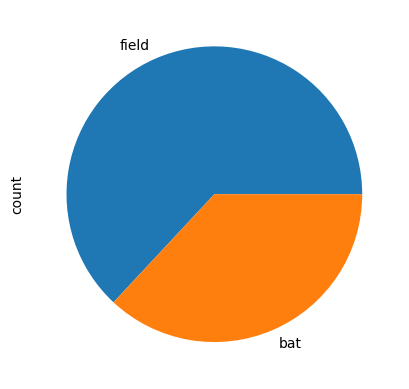

In [ ]:
# after toss decision plot
after_toss = ipl["TossDecision"].value_counts()
after_toss.plot(kind="pie")


In [ ]:
# how many matches has each team played
ipl.head(3)
(ipl["Team1"].value_counts() + ipl['Team2'].value_counts()).sort_values(ascending = True)

,count
Kochi Tuskers Kerala,14
Rising Pune Supergiants,14
Lucknow Super Giants,15
Gujarat Titans,16
Rising Pune Supergiant,16
Punjab Kings,28
Gujarat Lions,30
Pune Warriors,46
Delhi Capitals,63
Deccan Chargers,75


In [ ]:
movies = pd.read_csv('movies.csv')
movies.head(1)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)


In [ ]:
# sort_values (series and dataframe)
# sorts the series and

movies['title_x'].sort_values()   # just returns the sorted values

movies.sort_values('title_x')     # sorts and returns whole table according to a single column
movies.sort_values('title_x',ascending=False)     # sorts and returns whole table according to a single column



,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
1623,Zubeidaa,tt0255713,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zubeidaa,Zubeidaa,Zubeidaa,0,2001,153,Biography|Drama|History,6.2,1384,The film begins with Riyaz (Rajat Kapoor) Zub...,Zubeidaa an aspiring Muslim actress marries ...,The Story of a Princess,Karisma Kapoor|Rekha|Manoj Bajpayee|Rajit Kapo...,3 wins & 13 nominations,19 January 2001 (India)
939,Zor Lagaa Ke...Haiya!,tt1479857,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zor_Lagaa_Ke...H...,Zor Lagaa Ke... Haiya!,Zor Lagaa Ke... Haiya!,0,2009,\N,Comedy|Drama|Family,6.4,46,A tree narrates the story of four Mumbai-based...,Children build a tree-house to spy on a beggar...,NaN,Meghan Jadhav|Mithun Chakraborty|Riya Sen|Seem...,NaN,NaN
756,Zokkomon,tt1605790,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zokkomon,Zokkomon,Zokkomon,0,2011,109,Action|Adventure,4.0,274,After the passing of his parents in an acciden...,An orphan is abused and abandoned believed to...,Betrayal. Friendship. Bravery.,Darsheel Safary|Anupam Kher|Manjari Fadnnis|Ti...,NaN,22 April 2011 (India)
670,Zindagi Tere Naam,tt2164702,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zindagi_Tere_Naam,Zindagi Tere Naam,Zindagi Tere Naam,0,2012,120,Romance,4.7,27,Mr. Singh an elderly gentleman relates to hi...,Mr. Singh an elderly gentleman relates to hi...,NaN,Mithun Chakraborty|Ranjeeta Kaur|Priyanka Meht...,1 win,16 March 2012 (India)
778,Zindagi Na Milegi Dobara,tt1562872,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zindagi_Na_Mileg...,Zindagi Na Milegi Dobara,Zindagi Na Milegi Dobara,0,2011,155,Comedy|Drama,8.1,60826,Three friends decide to turn their fantasy vac...,Three friends decide to turn their fantasy vac...,NaN,Hrithik Roshan|Farhan Akhtar|Abhay Deol|Katrin...,30 wins & 22 nominations,15 July 2011 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039,1971 (2007 film),tt0983990,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/1971_(2007_film),1971,1971,0,2007,160,Action|Drama|War,7.9,1121,Based on true facts the film revolves around ...,Based on true facts the film revolves around ...,Honor the heroes.......,Manoj Bajpayee|Ravi Kishan|Deepak Dobriyal|,1 win,9 March 2007 (India)
723,1920: The Evil Returns,tt2222550,https://upload.wikimedia.org/wikipedia/en/e/e7...,https://en.wikipedia.org/wiki/1920:_The_Evil_R...,1920: Evil Returns,1920: Evil Returns,0,2012,124,Drama|Horror|Romance,4.8,1587,This story revolves around a famous poet who m...,This story revolves around a famous poet who m...,Possession is back,Vicky Ahuja|Tia Bajpai|Irma Jämhammar|Sharad K...,NaN,2 November 2012 (India)
287,1920: London,tt5638500,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/1920_London,1920 London,1920 London,0,2016,120,Horror|Mystery,4.1,1373,Shivangi (Meera Chopra) lives in London with h...,After her husband is possessed by an evil spir...,Fear strikes again,Sharman Joshi|Meera Chopra|Vishal Karwal|Suren...,NaN,6 May 2016 (USA)
1021,1920 (film),tt1301698,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/1920_(film),1920,1920,0,2008,138,Horror|Mystery|Romance,6.4,2588,A devotee of Bhagwan Shri Hanuman Arjun Singh...,After forsaking his family and religion a hus...,A Love Made in Heaven...A Revenge Born in Hell...,Rajniesh Duggall|Adah Sharma|Anjori Alagh|Raj ...,NaN,12 September 2008 (India)


In [ ]:
students = pd.DataFrame(
    {
        'name':['nitish','ankit','rupesh',np.nan,'mrityunjay',np.nan,'rishabh',np.nan,'aditya',np.nan],
        'college':['bit','iit','vit',np.nan,np.nan,'vlsi','ssit',np.nan,np.nan,'git'],
        'branch':['eee','it','cse',np.nan,'me','ce','civ','cse','bio',np.nan],
        'cgpa':[6.66,8.25,6.41,np.nan,5.6,9.0,7.4,10,7.4,np.nan],
        'package':[4,5,6,np.nan,6,7,8,9,np.nan,np.nan]

    }
)
students


,name,college,branch,cgpa,package
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0
2,rupesh,vit,cse,6.41,6.0
3,NaN,NaN,NaN,NaN,NaN
4,mrityunjay,NaN,me,5.60,6.0
5,NaN,vlsi,ce,9.00,7.0
6,rishabh,ssit,civ,7.40,8.0
7,NaN,NaN,cse,10.00,9.0
8,aditya,NaN,bio,7.40,NaN
9,NaN,git,NaN,NaN,NaN


In [ ]:
# what happens if we apply sort on a datsframe with missing values
students.sort_values("name")
# stores the nan values at the last of the program.

,name,college,branch,cgpa,package
8,aditya,NaN,bio,7.40,NaN
1,ankit,iit,it,8.25,5.0
4,mrityunjay,NaN,me,5.60,6.0
0,nitish,bit,eee,6.66,4.0
6,rishabh,ssit,civ,7.40,8.0
2,rupesh,vit,cse,6.41,6.0
3,NaN,NaN,NaN,NaN,NaN
5,NaN,vlsi,ce,9.00,7.0
7,NaN,NaN,cse,10.00,9.0
9,NaN,git,NaN,NaN,NaN


In [ ]:
students.sort_values('name',na_position='first',ascending = False)
# by ascending = false the nan value come to the top
# this sorting is not done inplace i.e permament , since theresylt is displayed automatically

,name,college,branch,cgpa,package
3,NaN,NaN,NaN,NaN,NaN
5,NaN,vlsi,ce,9.00,7.0
7,NaN,NaN,cse,10.00,9.0
9,NaN,git,NaN,NaN,NaN
2,rupesh,vit,cse,6.41,6.0
6,rishabh,ssit,civ,7.40,8.0
0,nitish,bit,eee,6.66,4.0
4,mrityunjay,NaN,me,5.60,6.0
1,ankit,iit,it,8.25,5.0
8,aditya,NaN,bio,7.40,NaN


In [ ]:
# to make the result permanent we use inplace parameter
students.sort_values('name',na_position='first',ascending = False, inplace= True)

In [ ]:
students

,name,college,branch,cgpa,package
3,NaN,NaN,NaN,NaN,NaN
5,NaN,vlsi,ce,9.00,7.0
7,NaN,NaN,cse,10.00,9.0
9,NaN,git,NaN,NaN,NaN
2,rupesh,vit,cse,6.41,6.0
6,rishabh,ssit,civ,7.40,8.0
0,nitish,bit,eee,6.66,4.0
4,mrityunjay,NaN,me,5.60,6.0
1,ankit,iit,it,8.25,5.0
8,aditya,NaN,bio,7.40,NaN


In [ ]:
movies.sort_values(['year_of_release','title_x'])
# first the data will be srted according to the first parameter, and then according to the second paramter, both in ascending order

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
1575,Aalavandhan,tt0294264,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Aalavandhan,Aalavandhan,Aalavandhan,0,2001,177,Action|Thriller,7.1,1746,The story follows Abhay (Haasan) who has a dis...,A psychopath tries to protect his twin brother...,The Fearless,Kamal Haasan|Raveena Tandon|Manisha Koirala|Ki...,1 win & 1 nomination,16 November 2001 (India)
1576,Aamdani Atthanni Kharcha Rupaiya,tt0305173,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Aamdani_Atthanni...,Aamdani Atthanni Kharcha Rupaiya,Aamdani Atthanni Kharcha Rupaiya,0,2001,150,Comedy|Drama|Family,4.7,1026,Jhoomri and her husband Bhimsha move into a ...,In order to make ends meet three women steps ...,NaN,Govinda|Juhi Chawla|Tabu|Chandrachur Singh|Joh...,1 nomination,21 December 2001 (India)
1577,Aashiq (2001 film),tt0273406,https://upload.wikimedia.org/wikipedia/en/c/c6...,https://en.wikipedia.org/wiki/Aashiq_(2001_film),Aashiq,Aashiq,0,2001,160,Action|Drama|Romance,3.8,357,Pooja and Chander Kapoor have a heart-to-heart...,Pooja and Chander Kapoor have a heart-to-heart...,NaN,Bobby Deol|Karisma Kapoor|,NaN,26 January 2001 (India)
1579,Ajnabee (2001 film),tt0278291,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Ajnabee_(2001_film),Ajnabee,Ajnabee,0,2001,165,Action|Crime|Drama,6.3,7480,A new couple get married and move to Switzerla...,Bobby Deol and Kareena Kapoor play a new coupl...,Trust no one,Akshay Kumar|Bobby Deol|Kareena Kapoor|Bipasha...,3 wins & 9 nominations,21 September 2001 (India)
1578,Aks (2001 film),tt0289845,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Aks_(2001_film),Aks,Aks,0,2001,184,Action|Crime|Horror,5.9,1518,Aks is the story of a hunter and his prey. A c...,Raghavan Ghatge a psychotic terrorist and Ma...,There is a stranger in your mirror,Amitabh Bachchan|Raveena Tandon|Manoj Bajpayee...,9 wins & 14 nominations,13 July 2001 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,Ujda Chaman,tt11046300,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Ujda_Chaman,Ujda Chaman,Ujda Chaman,0,2019,120,Comedy,8.1,1440,Ujda Chaman is about a 30 -year-old bachelor C...,Ujda Chaman is about a 30 -year-old bachelor C...,NaN,Sunny Singh Nijjar|Maanvi Gagroo|Saurabh Shukl...,NaN,1 November 2019 (USA)
0,Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
60,Yaaram (2019 film),tt11007050,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yaaram_(2019_film),#Yaaram,#Yaaram,0,2019,\N,Comedy|Romance,5.7,7,All set for an arranged marriage Rohit Bajaj ...,All set for an arranged marriage Rohit Bajaj ...,NaN,Siddhanth Kapoor|Prateik|Anita Raj|Ishita Raj|...,NaN,NaN


In [ ]:
# if we want to arrange according to the year of release in ascending order , while in descending order according to the title_x
movies.sort_values(['year_of_release','title_x'],ascending= [True,False])

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
1623,Zubeidaa,tt0255713,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Zubeidaa,Zubeidaa,Zubeidaa,0,2001,153,Biography|Drama|History,6.2,1384,The film begins with Riyaz (Rajat Kapoor) Zub...,Zubeidaa an aspiring Muslim actress marries ...,The Story of a Princess,Karisma Kapoor|Rekha|Manoj Bajpayee|Rajit Kapo...,3 wins & 13 nominations,19 January 2001 (India)
1625,Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
1622,Yeh Teraa Ghar Yeh Meraa Ghar,tt0298606,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Teraa_Ghar_Y...,Yeh Teraa Ghar Yeh Meraa Ghar,Yeh Teraa Ghar Yeh Meraa Ghar,0,2001,175,Comedy|Drama,5.7,704,In debt; Dayashankar Pandey is forced to go to...,In debt; Dayashankar Pandey is forced to go to...,NaN,Sunil Shetty|Mahima Chaudhry|Paresh Rawal|Saur...,1 nomination,12 October 2001 (India)
1620,Yeh Raaste Hain Pyaar Ke,tt0292740,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Raaste_Hain_...,Yeh Raaste Hain Pyaar Ke,Yeh Raaste Hain Pyaar Ke,0,2001,149,Drama|Romance,4.0,607,Two con artistes and car thieves Vicky (Ajay ...,Two con artistes and car thieves Vicky (Ajay ...,Love is a journey... not a destination,Ajay Devgn|Madhuri Dixit|Preity Zinta|Vikram G...,NaN,10 August 2001 (India)
1573,Yaadein (2001 film),tt0248617,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yaadein_(2001_film),Yaadein...,Yaadein...,0,2001,171,Drama|Musical|Romance,4.4,3034,Raj Singh Puri is best friends with L.K. Malho...,Raj Singh Puri is best friends with L.K. Malho...,memories to cherish...,Jackie Shroff|Hrithik Roshan|Kareena Kapoor|Am...,1 nomination,27 June 2001 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,Article 15 (film),tt10324144,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Article_15_(film),Article 15,Article 15,0,2019,130,Crime|Drama,8.3,13417,In the rural heartlands of India an upright p...,In the rural heartlands of India an upright p...,Farq Bahut Kar Liya| Ab Farq Laayenge.,Ayushmann Khurrana|Nassar|Manoj Pahwa|Kumud Mi...,1 win,28 June 2019 (USA)
46,Arjun Patiala,tt7881524,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Arjun_Patiala,Arjun Patiala,Arjun Patiala,0,2019,107,Action|Comedy,4.1,676,Arjun Patiala(Diljit Dosanjh)has recently been...,This spoof comedy narrates the story of a cop ...,NaN,Diljit Dosanjh|Kriti Sanon|Varun Sharma|Ronit ...,NaN,26 July 2019 (USA)
10,Amavas,tt8396186,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Amavas,Amavas,Amavas,0,2019,134,Horror|Thriller,2.8,235,Far away from the bustle of the city a young ...,The lives of a couple turn into a nightmare a...,NaN,Ali Asgar|Vivan Bhatena|Nargis Fakhri|Sachiin ...,NaN,8 February 2019 (India)
26,Albert Pinto Ko Gussa Kyun Aata Hai?,tt4355838,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Albert_Pinto_Ko_...,Albert Pinto Ko Gussa Kyun Aata Hai?,Albert Pinto Ko Gussa Kyun Aata Hai?,0,2019,100,Drama,4.8,56,Albert leaves his house one morning without te...,Albert Pinto goes missing one day and his girl...,NaN,Manav Kaul|Nandita Das|,NaN,12 April 2019 (India)


In [ ]:
# rank (series)
runs = pd.read_csv('batsman_runs_ipl.csv')
runs

,batter,batsman_run
0,A Ashish Reddy,280
1,A Badoni,161
2,A Chandila,4
3,A Chopra,53
4,A Choudhary,25
...,...,...
600,Yash Dayal,0
601,Yashpal Singh,47
602,Younis Khan,3
603,Yuvraj Singh,2754


In [ ]:
runs['batsman_run'].rank()   # by default ascending order me ranking hoti hai

,batsman_run
0,439.5
1,380.0
2,71.0
3,277.0
4,203.5
...,...
600,12.0
601,263.0
602,58.5
603,579.0


In [ ]:
runs['batsman_rank'] = runs['batsman_run'].rank(ascending=False)
runs.sort_values('batsman_rank')

# in rank function all same runs are at same rank

,batter,batsman_run,batsman_rank
569,V Kohli,6634,1.0
462,S Dhawan,6244,2.0
130,DA Warner,5883,3.0
430,RG Sharma,5881,4.0
493,SK Raina,5536,5.0
...,...,...,...
570,V Pratap Singh,0,594.0
63,Abdur Razzak,0,594.0
562,U Kaul,0,594.0
65,Akash Deep,0,594.0


In [ ]:
# sort_index (series and dataframe)  same behaviour in both
marks = {
    'maths':67,
    'english':57,
    'science':89,
    'hindi':100
}

marks_series = pd.Series(marks)
marks_series

,0
maths,67
english,57
science,89
hindi,100


In [ ]:
marks_series.sort_index()
marks_series.sort_index(ascending = False)

,0
science,89
maths,67
hindi,100
english,57


In [ ]:
movies.sort_index(ascending = False)

,title_x,imdb_id,poster_path,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
1628,Humsafar,tt2403201,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Humsafar,Humsafar,Humsafar,0,2011,35,Drama|Romance,9.0,2968,Sara and Ashar are childhood friends who share...,Ashar and Khirad are forced to get married due...,NaN,Fawad Khan|,NaN,TV Series (2011–2012)
1627,Daaka,tt10833860,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Daaka,Daaka,Daaka,0,2019,136,Action,7.4,38,Shinda tries robbing a bank so he can be wealt...,Shinda tries robbing a bank so he can be wealt...,NaN,Gippy Grewal|Zareen Khan|,NaN,1 November 2019 (USA)
1626,Sabse Bada Sukh,tt0069204,NaN,https://en.wikipedia.org/wiki/Sabse_Bada_Sukh,Sabse Bada Sukh,Sabse Bada Sukh,0,2018,\N,Comedy|Drama,6.1,13,Village born Lalloo re-locates to Bombay and ...,Village born Lalloo re-locates to Bombay and ...,NaN,Vijay Arora|Asrani|Rajni Bala|Kumud Damle|Utpa...,NaN,NaN
1625,Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
1624,Tera Mera Saath Rahen,tt0301250,https://upload.wikimedia.org/wikipedia/en/2/2b...,https://en.wikipedia.org/wiki/Tera_Mera_Saath_...,Tera Mera Saath Rahen,Tera Mera Saath Rahen,0,2001,148,Drama,4.9,278,Raj Dixit lives with his younger brother Rahu...,A man is torn between his handicapped brother ...,NaN,Ajay Devgn|Sonali Bendre|Namrata Shirodkar|Pre...,NaN,7 November 2001 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)
3,Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
2,The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
1,Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)


In [ ]:
# set_index (dataframe)  --> inplace
runs.set_index('batter')   # not a permanent change

,batsman_run,batsman_rank
batter,,
A Ashish Reddy,280,166.5
A Badoni,161,226.0
A Chandila,4,535.0
A Chopra,53,329.0
A Choudhary,25,402.5
...,...,...
Yash Dayal,0,594.0
Yashpal Singh,47,343.0
Younis Khan,3,547.5


In [ ]:
runs.set_index('batter',inplace=True)   # permanent change
# gives no output sutomatically so it makes the changes permanent

In [ ]:
# reset_index (series , dataframe)   --> drop parameter

runs.reset_index()      # not a permanent change
# runs.reset_index(inplace = True)   # a permanent change

,batter,batsman_run,batsman_rank
0,A Ashish Reddy,280,166.5
1,A Badoni,161,226.0
2,A Chandila,4,535.0
3,A Chopra,53,329.0
4,A Choudhary,25,402.5
...,...,...,...
600,Yash Dayal,0,594.0
601,Yashpal Singh,47,343.0
602,Younis Khan,3,547.5
603,Yuvraj Singh,2754,27.0


In [ ]:
runs

,batsman_run,batsman_rank
batter,,
A Ashish Reddy,280,166.5
A Badoni,161,226.0
A Chandila,4,535.0
A Chopra,53,329.0
A Choudhary,25,402.5
...,...,...
Yash Dayal,0,594.0
Yashpal Singh,47,343.0
Younis Khan,3,547.5


In [ ]:
# how to replace existing index without loosing column

# to make the batsman_rank the index inplace of batter without loosing batter
# first we do reset_index() then set_index()
runs.reset_index().set_index('batsman_rank')

,batter,batsman_run
batsman_rank,,
166.5,A Ashish Reddy,280
226.0,A Badoni,161
535.0,A Chandila,4
329.0,A Chopra,53
402.5,A Choudhary,25
...,...,...
594.0,Yash Dayal,0
343.0,Yashpal Singh,47
547.5,Younis Khan,3


In [ ]:
# convert series to dataframe using reset_index
print(marks_series.reset_index())   # the series 'marks_series' is automatically converted to dataframe
print(type(marks_series.reset_index()))

     index    0
0    maths   67
1  english   57
2  science   89
3    hindi  100
<class 'pandas.core.frame.DataFrame'>


In [ ]:
# rename(dataframe)  --> index    --> we can change columns name also we can change index name
movies.set_index('title_x',inplace = True)

KeyError: "None of ['title_x'] are in the columns"

In [ ]:
movies.rename(columns = {'imdb_id':'imdb','poster_path':'link'},inplace=True)

In [ ]:
movies

,imdb,link,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
title_x,,,,,,,,,,,,,,,,,
Uri: The Surgical Strike,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
Battalion 609,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Tera Mera Saath Rahen,tt0301250,https://upload.wikimedia.org/wikipedia/en/2/2b...,https://en.wikipedia.org/wiki/Tera_Mera_Saath_...,Tera Mera Saath Rahen,Tera Mera Saath Rahen,0,2001,148,Drama,4.9,278,Raj Dixit lives with his younger brother Rahu...,A man is torn between his handicapped brother ...,NaN,Ajay Devgn|Sonali Bendre|Namrata Shirodkar|Pre...,NaN,7 November 2001 (India)
Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
Sabse Bada Sukh,tt0069204,NaN,https://en.wikipedia.org/wiki/Sabse_Bada_Sukh,Sabse Bada Sukh,Sabse Bada Sukh,0,2018,\N,Comedy|Drama,6.1,13,Village born Lalloo re-locates to Bombay and ...,Village born Lalloo re-locates to Bombay and ...,NaN,Vijay Arora|Asrani|Rajni Bala|Kumud Damle|Utpa...,NaN,NaN


In [ ]:
movies.rename(index={'Uri: The Surgical Strike':'Uri','Battalion 609':'Battalion'})

,imdb,link,wiki_link,title_y,original_title,is_adult,year_of_release,runtime,genres,imdb_rating,imdb_votes,story,summary,tagline,actors,wins_nominations,release_date
title_x,,,,,,,,,,,,,,,,,
Uri,tt8291224,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Uri:_The_Surgica...,Uri: The Surgical Strike,Uri: The Surgical Strike,0,2019,138,Action|Drama|War,8.4,35112,Divided over five chapters the film chronicle...,Indian army special forces execute a covert op...,NaN,Vicky Kaushal|Paresh Rawal|Mohit Raina|Yami Ga...,4 wins,11 January 2019 (USA)
Battalion,tt9472208,NaN,https://en.wikipedia.org/wiki/Battalion_609,Battalion 609,Battalion 609,0,2019,131,War,4.1,73,The story revolves around a cricket match betw...,The story of Battalion 609 revolves around a c...,NaN,Vicky Ahuja|Shoaib Ibrahim|Shrikant Kamat|Elen...,NaN,11 January 2019 (India)
The Accidental Prime Minister (film),tt6986710,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/The_Accidental_P...,The Accidental Prime Minister,The Accidental Prime Minister,0,2019,112,Biography|Drama,6.1,5549,Based on the memoir by Indian policy analyst S...,Explores Manmohan Singh's tenure as the Prime ...,NaN,Anupam Kher|Akshaye Khanna|Aahana Kumra|Atul S...,NaN,11 January 2019 (USA)
Why Cheat India,tt8108208,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Why_Cheat_India,Why Cheat India,Why Cheat India,0,2019,121,Crime|Drama,6.0,1891,The movie focuses on existing malpractices in ...,The movie focuses on existing malpractices in ...,NaN,Emraan Hashmi|Shreya Dhanwanthary|Snighdadeep ...,NaN,18 January 2019 (USA)
Evening Shadows,tt6028796,NaN,https://en.wikipedia.org/wiki/Evening_Shadows,Evening Shadows,Evening Shadows,0,2018,102,Drama,7.3,280,While gay rights and marriage equality has bee...,Under the 'Evening Shadows' truth often plays...,NaN,Mona Ambegaonkar|Ananth Narayan Mahadevan|Deva...,17 wins & 1 nomination,11 January 2019 (India)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Tera Mera Saath Rahen,tt0301250,https://upload.wikimedia.org/wikipedia/en/2/2b...,https://en.wikipedia.org/wiki/Tera_Mera_Saath_...,Tera Mera Saath Rahen,Tera Mera Saath Rahen,0,2001,148,Drama,4.9,278,Raj Dixit lives with his younger brother Rahu...,A man is torn between his handicapped brother ...,NaN,Ajay Devgn|Sonali Bendre|Namrata Shirodkar|Pre...,NaN,7 November 2001 (India)
Yeh Zindagi Ka Safar,tt0298607,https://upload.wikimedia.org/wikipedia/en/thum...,https://en.wikipedia.org/wiki/Yeh_Zindagi_Ka_S...,Yeh Zindagi Ka Safar,Yeh Zindagi Ka Safar,0,2001,146,Drama,3.0,133,Hindi pop-star Sarina Devan lives a wealthy ...,A singer finds out she was adopted when the ed...,NaN,Ameesha Patel|Jimmy Sheirgill|Nafisa Ali|Gulsh...,NaN,16 November 2001 (India)
Sabse Bada Sukh,tt0069204,NaN,https://en.wikipedia.org/wiki/Sabse_Bada_Sukh,Sabse Bada Sukh,Sabse Bada Sukh,0,2018,\N,Comedy|Drama,6.1,13,Village born Lalloo re-locates to Bombay and ...,Village born Lalloo re-locates to Bombay and ...,NaN,Vijay Arora|Asrani|Rajni Bala|Kumud Damle|Utpa...,NaN,NaN


In [ ]:
# unique  (series)
temp = pd.Series([1,1,2,np.nan,3,4,np.nan,5,3,2,1])
print(temp.unique())
print(len(temp.unique()))

# counts all first occurences of unique value , also counts nan

[ 1.  2. nan  3.  4.  5.]
6


In [ ]:
len(ipl['Season'].unique())    # no of uniwue values or run nunique

15

In [ ]:
# nunique  (series , dataframe)  --> does not count nan
print(ipl['Season'].nunique())
print(temp.nunique())

# see above in len(temp.unique()) value is +1 since it also counts 'nan'

15
5


In [ ]:
students

,name,college,branch,cgpa,package
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0
2,rupesh,vit,cse,6.41,6.0
3,NaN,NaN,NaN,NaN,NaN
4,mrityunjay,NaN,me,5.60,6.0
5,NaN,vlsi,ce,9.00,7.0
6,rishabh,ssit,civ,7.40,8.0
7,NaN,NaN,cse,10.00,9.0
8,aditya,NaN,bio,7.40,NaN
9,NaN,git,NaN,NaN,NaN


In [ ]:
# tells whether ther are missing value in the dataframe or not

# isnull  (series, dataframe)
# notnull (series, dataframe)
# hasnans (series)


In [ ]:
# isnull
students[students['name'].isnull()]   # students['name'].isnull() outputs a boolean array

,name,college,branch,cgpa,package
3,NaN,NaN,NaN,NaN,NaN
5,NaN,vlsi,ce,9.0,7.0
7,NaN,NaN,cse,10.0,9.0
9,NaN,git,NaN,NaN,NaN


In [ ]:
# notnull  --> just complementory of isnull
students[students['name'].notnull()]

,name,college,branch,cgpa,package
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0
2,rupesh,vit,cse,6.41,6.0
4,mrityunjay,NaN,me,5.60,6.0
6,rishabh,ssit,civ,7.40,8.0
8,aditya,NaN,bio,7.40,NaN


In [ ]:
# hasnan  (series, dataframe)
students['name'].hasnans

True

In [ ]:
# applying on a whole dataframe
students.isnull()

,name,college,branch,cgpa,package
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,True,True,True,True,True
4,False,True,False,False,False
5,True,False,False,False,False
6,False,False,False,False,False
7,True,True,False,False,False
8,False,True,False,False,True
9,True,False,True,True,True


In [ ]:
students.notnull()  #---> complemet of isnull

,name,college,branch,cgpa,package
0,True,True,True,True,True
1,True,True,True,True,True
2,True,True,True,True,True
3,False,False,False,False,False
4,True,False,True,True,True
5,False,True,True,True,True
6,True,True,True,True,True
7,False,False,True,True,True
8,True,False,True,True,False
9,False,True,False,False,False


In [ ]:
# what to do when null values are found in the dataset

# dropna  (series, dataframe)   -->how parameter,  not permanent changes use inplace parameter

students['name'].dropna()   # applied on a single column (series)

,name
0,nitish
1,ankit
2,rupesh
4,mrityunjay
6,rishabh
8,aditya


In [ ]:
students.dropna()
# if there's atleast one nan in any row the whole row will get removed

,name,college,branch,cgpa,package
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0
2,rupesh,vit,cse,6.41,6.0
6,rishabh,ssit,civ,7.40,8.0


In [ ]:
# has hidden parameter has = 'any'

# say if we want to remove those rows whole all values are missing
students.dropna(how= 'all')

,name,college,branch,cgpa,package
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0
2,rupesh,vit,cse,6.41,6.0
4,mrityunjay,NaN,me,5.60,6.0
5,NaN,vlsi,ce,9.00,7.0
6,rishabh,ssit,civ,7.40,8.0
7,NaN,NaN,cse,10.00,9.0
8,aditya,NaN,bio,7.40,NaN
9,NaN,git,NaN,NaN,NaN


In [ ]:
# lets say i want to remove all nan in name column
students.dropna(subset=['name'])

,name,college,branch,cgpa,package
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0
2,rupesh,vit,cse,6.41,6.0
4,mrityunjay,NaN,me,5.60,6.0
6,rishabh,ssit,civ,7.40,8.0
8,aditya,NaN,bio,7.40,NaN


In [ ]:
# lets say i want to remove all nan in name column or college column
students.dropna(subset = ['name', 'college'])

,name,college,branch,cgpa,package
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0
2,rupesh,vit,cse,6.41,6.0
6,rishabh,ssit,civ,7.40,8.0


In [ ]:
# fillna (series, dataframe)  --> fill the missing data

# although the fillna works with dataframe but it is not advised to do so, the missing values must always be filled column by column

students['name'].fillna('unknown')   # fill the missing data with 'unknown'

,name
0,nitish
1,ankit
2,rupesh
3,unknown
4,mrityunjay
5,unknown
6,rishabh
7,unknown
8,aditya
9,unknown


In [ ]:
students.fillna(0)

,name,college,branch,cgpa,package
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0
2,rupesh,vit,cse,6.41,6.0
3,0,0,0,0.00,0.0
4,mrityunjay,0,me,5.60,6.0
5,0,vlsi,ce,9.00,7.0
6,rishabh,ssit,civ,7.40,8.0
7,0,0,cse,10.00,9.0
8,aditya,0,bio,7.40,0.0
9,0,git,0,0.00,0.0


In [ ]:
students['name'].fillna(method= 'ffill')   # in nan's place the previous value will be filled
# there is also a method = 'bfill'  which fills the nan with next value

/tmp/ipykernel_5542/3980606652.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  students['name'].fillna(method= 'ffill')


,name
0,nitish
1,ankit
2,rupesh
3,rupesh
4,mrityunjay
5,mrityunjay
6,rishabh
7,rishabh
8,aditya
9,aditya


In [ ]:
# drop_duplicates  (series, dataframe)   --> works like duplicated()
marks = pd.DataFrame([
    [100,80,10],
    [90,70,7],
    [120,100,14],
    [80,70,14],
    [80,70,14]
],columns=['iq','marks','package'])

marks

,iq,marks,package
0,100,80,10
1,90,70,7
2,120,100,14
3,80,70,14
4,80,70,14


In [ ]:
marks.duplicated()  # tells how many no of rows are duplicated
print(marks.duplicated().sum())

1


In [ ]:
temp = pd.Series([1,1,1,2,3,3,4,4])
temp.drop_duplicates()    # all duplicated values are removed in the series

,0
0,1
3,2
4,3
6,4


In [ ]:
# applying in a dataframe
marks.drop_duplicates()
marks.drop_duplicates(keep='first')   # keeps the first occurence of the duplicated value
marks.drop_duplicates(keep='last')   # keeps the last occurence of the duplicated value

,iq,marks,package
0,100,80,10
1,90,70,7
2,120,100,14
4,80,70,14


In [ ]:
# lets say we have to find the last match among all the matches in which virat kohli played in delhi
ipl['all_players'] = ipl['Team1Players'] + ipl['Team2Players']
ipl.head()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,...,WinningTeam,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,all_players
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,...,Gujarat Titans,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ..."
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,...,Rajasthan Royals,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ..."
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,...,Royal Challengers Bangalore,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ..."
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,...,Gujarat Titans,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ..."
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,...,Punjab Kings,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ..."


In [ ]:
def did_kohli_play(players):
  return 'V Kohli' in players

In [ ]:
ipl['did_kohli_play'] = ipl['all_players'].apply(did_kohli_play)
ipl.head()

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,...,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,all_players,did_kohli_play
0,1312200,Ahmedabad,2022-05-29,2022,Final,Rajasthan Royals,Gujarat Titans,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,bat,...,Wickets,7.0,NaN,HH Pandya,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",CB Gaffaney,Nitin Menon,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",False
1,1312199,Ahmedabad,2022-05-27,2022,Qualifier 2,Royal Challengers Bangalore,Rajasthan Royals,"Narendra Modi Stadium, Ahmedabad",Rajasthan Royals,field,...,Wickets,7.0,NaN,JC Buttler,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",CB Gaffaney,Nitin Menon,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...",True
2,1312198,Kolkata,2022-05-25,2022,Eliminator,Royal Challengers Bangalore,Lucknow Super Giants,"Eden Gardens, Kolkata",Lucknow Super Giants,field,...,Runs,14.0,NaN,RM Patidar,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...","['Q de Kock', 'KL Rahul', 'M Vohra', 'DJ Hooda...",J Madanagopal,MA Gough,"['V Kohli', 'F du Plessis', 'RM Patidar', 'GJ ...",True
3,1312197,Kolkata,2022-05-24,2022,Qualifier 1,Rajasthan Royals,Gujarat Titans,"Eden Gardens, Kolkata",Gujarat Titans,field,...,Wickets,7.0,NaN,DA Miller,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...","['WP Saha', 'Shubman Gill', 'MS Wade', 'HH Pan...",BNJ Oxenford,VK Sharma,"['YBK Jaiswal', 'JC Buttler', 'SV Samson', 'D ...",False
4,1304116,Mumbai,2022-05-22,2022,70,Sunrisers Hyderabad,Punjab Kings,"Wankhede Stadium, Mumbai",Sunrisers Hyderabad,bat,...,Wickets,5.0,NaN,Harpreet Brar,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...","['JM Bairstow', 'S Dhawan', 'M Shahrukh Khan',...",AK Chaudhary,NA Patwardhan,"['PK Garg', 'Abhishek Sharma', 'RA Tripathi', ...",False


In [ ]:
ipl[(ipl['City'] == 'Delhi') & (ipl['did_kohli_play'] == True)].drop_duplicates(subset=['City','did_kohli_play'])

,ID,City,Date,Season,MatchNumber,Team1,Team2,Venue,TossWinner,TossDecision,...,WonBy,Margin,method,Player_of_Match,Team1Players,Team2Players,Umpire1,Umpire2,all_players,did_kohli_play
208,1178421,Delhi,2019-04-28,2019,46,Delhi Capitals,Royal Challengers Bangalore,Arun Jaitley Stadium,Delhi Capitals,bat,...,Runs,16.0,NaN,S Dhawan,"['PP Shaw', 'S Dhawan', 'SS Iyer', 'RR Pant', ...","['PA Patel', 'V Kohli', 'AB de Villiers', 'S D...",BNJ Oxenford,KN Ananthapadmanabhan,"['PP Shaw', 'S Dhawan', 'SS Iyer', 'RR Pant', ...",True


In [ ]:
# drop(series + dataframe)
temp = pd.Series([10,2,3,16,45,78,10])
temp

,0
0,10
1,2
2,3
3,16
4,45
5,78
6,10


In [ ]:
temp.drop(index=[0,6])

,0
1,2
2,3
3,16
4,45
5,78


In [ ]:
students

,name,college,branch,cgpa,package
0,nitish,bit,eee,6.66,4.0
1,ankit,iit,it,8.25,5.0
2,rupesh,vit,cse,6.41,6.0
3,NaN,NaN,NaN,NaN,NaN
4,mrityunjay,NaN,me,5.60,6.0
5,NaN,vlsi,ce,9.00,7.0
6,rishabh,ssit,civ,7.40,8.0
7,NaN,NaN,cse,10.00,9.0
8,aditya,NaN,bio,7.40,NaN
9,NaN,git,NaN,NaN,NaN


In [ ]:
students.drop(columns=['branch','cgpa'],inplace=True)

In [ ]:
students

,name,college,package
0,nitish,bit,4.0
1,ankit,iit,5.0
2,rupesh,vit,6.0
3,NaN,NaN,NaN
4,mrityunjay,NaN,6.0
5,NaN,vlsi,7.0
6,rishabh,ssit,8.0
7,NaN,NaN,9.0
8,aditya,NaN,NaN
9,NaN,git,NaN


In [ ]:
students.set_index('name').drop(index=['nitish','aditya'])   # can also drop rows

,college,package
name,,
ankit,iit,5.0
rupesh,vit,6.0
NaN,NaN,NaN
mrityunjay,NaN,6.0
NaN,vlsi,7.0
rishabh,ssit,8.0
NaN,NaN,9.0
NaN,git,NaN


In [ ]:
# apply(series + dataframe)
temp = pd.Series([10,20,30,40,50])

temp

,0
0,10
1,20
2,30
3,40
4,50


In [ ]:
def sigmoid(value):
  return 1/1+np.exp(-value)

In [ ]:
temp.apply(sigmoid)

,0
0,1.000045
1,1.000000
2,1.000000
3,1.000000
4,1.000000


In [ ]:
points_df = pd.DataFrame(
    {
        '1st point':[(3,4),(-6,5),(0,0),(-10,1),(4,5)],
        '2nd point':[(-3,4),(0,0),(2,2),(10,10),(1,1)]
    }
)

points_df

,1st point,2nd point
0,"(3, 4)","(-3, 4)"
1,"(-6, 5)","(0, 0)"
2,"(0, 0)","(2, 2)"
3,"(-10, 1)","(10, 10)"
4,"(4, 5)","(1, 1)"


In [ ]:
def euclidean(row):
  pt_A = row['1st point']
  pt_B = row['2nd point']

  return ((pt_A[0] - pt_B[0])**2 + (pt_A[1] - pt_B[1])**2)**0.5

In [ ]:
points_df['distance'] = points_df.apply(euclidean,axis=1)
points_df

,1st point,2nd point,distance
0,"(3, 4)","(-3, 4)",6.000000
1,"(-6, 5)","(0, 0)",7.810250
2,"(0, 0)","(2, 2)",2.828427
3,"(-10, 1)","(10, 10)",21.931712
4,"(4, 5)","(1, 1)",5.000000




---



In [ ]:
import numpy as np
import pandas as pd

In [ ]:
movies = pd.read_csv("/content/imdb-top-1000.csv")
movies.head(2)

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
0,The Shawshank Redemption,1994,142,Drama,9.3,Frank Darabont,Tim Robbins,2343110,28341469.0,80.0
1,The Godfather,1972,175,Crime,9.2,Francis Ford Coppola,Marlon Brando,1620367,134966411.0,100.0


In [ ]:
# group by
# two types of data --> numerical & categorical
# group by applies on categorical data i.e on the basis of genre

# SYNTAX:
genre = movies.groupby('Genre')

In [ ]:
# applying builtin aggregate function in groupby objects
genre.min()

,Series_Title,Released_Year,Runtime,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,
Action,300,1924,45,7.6,Abhishek Chaubey,Aamir Khan,25312,3296.0,33.0
Adventure,2001: A Space Odyssey,1925,88,7.6,Akira Kurosawa,Aamir Khan,29999,61001.0,41.0
Animation,Akira,1940,71,7.6,Adam Elliot,Adrian Molina,25229,128985.0,61.0
Biography,12 Years a Slave,1928,93,7.6,Adam McKay,Adrien Brody,27254,21877.0,48.0
Comedy,(500) Days of Summer,1921,68,7.6,Alejandro G. Iñárritu,Aamir Khan,26337,1305.0,45.0
Crime,12 Angry Men,1931,80,7.6,Akira Kurosawa,Ajay Devgn,27712,6013.0,47.0
Drama,1917,1925,64,7.6,Aamir Khan,Abhay Deol,25088,3600.0,28.0
Family,E.T. the Extra-Terrestrial,1971,100,7.8,Mel Stuart,Gene Wilder,178731,4000000.0,67.0
Fantasy,Das Cabinet des Dr. Caligari,1920,76,7.9,F.W. Murnau,Max Schreck,57428,337574718.0,NaN


In [ ]:
# find the top 3 genres with the most earning.
movies.groupby('Genre').sum()['Gross'].sort_values(ascending=False).head(3)



# another way of solving
movies.groupby('Genre')['Gross'].sum().sort_values(ascending=False).head(3)     # this one is much better since it is faster as it loads a single series before adding

,Gross
Genre,
Action,3.263226e+10
Adventure,9.496922e+09
Animation,1.463147e+10
Biography,8.276358e+09
Comedy,1.566387e+10
Crime,8.452632e+09
Drama,3.540997e+10
Family,4.391106e+08
Fantasy,7.827267e+08


In [ ]:
# find the genre with highest average IMDB rating
movies.groupby('Genre')['IMDB_Rating'].mean().sort_values(ascending=False).head(1)

,IMDB_Rating
Genre,
Western,8.35


In [ ]:
# find director with highest popularity
movies.groupby('Director')['No_of_Votes'].sum().sort_values(ascending=False).head(3)

,No_of_Votes
Director,
Christopher Nolan,11578345
Quentin Tarantino,8123208
Steven Spielberg,7817166


In [ ]:
# find the highest rated movie of each genre
movies.groupby('Genre')['IMDB_Rating'].max()    # movie of name is not appearing in this

,IMDB_Rating
Genre,
Action,9.0
Adventure,8.6
Animation,8.6
Biography,8.9
Comedy,8.6
Crime,9.2
Drama,9.3
Family,7.8
Fantasy,8.1


In [ ]:
# find no of movies done by each actor
movies.groupby('Star1')['Series_Title'].count().sort_values(ascending=False)


# another way
movies['Star1'].value_counts()

,count
Star1,
Tom Hanks,12
Robert De Niro,11
Al Pacino,10
Clint Eastwood,10
Humphrey Bogart,9
...,...
Junko Iwao,1
Fernanda Montenegro,1
Eli Marienthal,1


In [ ]:
# GroupBy Attributes and Methods
# find total number of groups -> len
# find items in each group -> size
# first()/last() -> nth item
# get_group -> vs filtering
# groups
# describe
# sample
# nunique

In [ ]:
# find total number of groups -> len
len(movies.groupby('Genre'))

# another way
movies['Genre'].nunique()

14

In [ ]:
# find items in each group -> size
movies.groupby('Genre').size()    # no of rows in each group

,0
Genre,
Action,172
Adventure,72
Animation,82
Biography,88
Comedy,155
Crime,107
Drama,289
Family,2
Fantasy,2


In [ ]:
# first()/last() -> nth item
genres = movies.groupby('Genre')
genres.first()      # extract first movie in each group
genres.last()       # extract last movies in each group

genres.nth(6)       # extract 7th movie in each group, written 6 bcz index starts from 0

# each group may not have 7 more movies , so only those groups are displayed who have at least 7 movies.

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
16,Star Wars: Episode V - The Empire Strikes Back,1980,124,Action,8.7,Irvin Kershner,Mark Hamill,1159315,290475067.0,82.0
27,Se7en,1995,127,Crime,8.6,David Fincher,Morgan Freeman,1445096,100125643.0,65.0
32,It's a Wonderful Life,1946,130,Drama,8.6,Frank Capra,James Stewart,405801,82385199.0,89.0
66,WALL·E,2008,98,Animation,8.4,Andrew Stanton,Ben Burtt,999790,223808164.0,95.0
83,The Great Dictator,1940,125,Comedy,8.4,Charles Chaplin,Charles Chaplin,203150,288475.0,NaN
102,Braveheart,1995,178,Biography,8.3,Mel Gibson,Mel Gibson,959181,75600000.0,68.0
118,North by Northwest,1959,136,Adventure,8.3,Alfred Hitchcock,Cary Grant,299198,13275000.0,98.0
420,Sleuth,1972,138,Mystery,8.0,Joseph L. Mankiewicz,Laurence Olivier,44748,4081254.0,NaN
724,Get Out,2017,104,Horror,7.7,Jordan Peele,Daniel Kaluuya,492851,176040665.0,85.0


In [ ]:
# get_group -> vs filtering

# to view all movies of a particular group
genres = movies.groupby('Genre')
genres.get_group('Fantasy')       # faster


# another way of doing so
movies[movies['Genre'] == 'Fantasy']

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
321,Das Cabinet des Dr. Caligari,1920,76,Fantasy,8.1,Robert Wiene,Werner Krauss,57428,337574718.0,NaN
568,Nosferatu,1922,94,Fantasy,7.9,F.W. Murnau,Max Schreck,88794,445151978.0,NaN


In [ ]:
# groups
genres.groups

# returns a dictionary whose key is genre and value is a list with index values of all the movies in that genre

{'Action': [2, 5, 8, 10, 13, 14, 16, 29, 30, 31, 39, 42, 44, 55, 57, 59, 60, 63, 68, 72, 106, 109, 129, 130, 134, 140, 142, 144, 152, 155, 160, 161, 166, 168, 171, 172, 177, 181, 194, 201, 202, 216, 217, 223, 224, 236, 241, 262, 275, 294, 308, 320, 325, 326, 331, 337, 339, 340, 343, 345, 348, 351, 353, 356, 357, 362, 368, 369, 375, 376, 390, 410, 431, 436, 473, 477, 479, 482, 488, 493, 496, 502, 507, 511, 532, 535, 540, 543, 564, 569, 570, 573, 577, 582, 583, 602, 605, 608, 615, 623, ...], 'Adventure': [21, 47, 93, 110, 114, 116, 118, 137, 178, 179, 191, 193, 209, 226, 231, 247, 267, 273, 281, 300, 301, 304, 306, 323, 329, 361, 366, 377, 402, 406, 415, 426, 458, 470, 497, 498, 506, 513, 514, 537, 549, 552, 553, 566, 576, 604, 609, 618, 638, 647, 675, 681, 686, 692, 711, 713, 739, 755, 781, 797, 798, 851, 873, 884, 912, 919, 947, 957, 964, 966, 984, 991], 'Animation': [23, 43, 46, 56, 58, 61, 66, 70, 101, 135, 146, 151, 158, 170, 197, 205, 211, 213, 219, 229, 230, 242, 245, 246, 270, 33

In [ ]:
# describe
genres = movies.groupby('Genre')
genres.describe()

Runtime                                                              \
            count        mean        std    min     25%    50%     75%    max   
Genre                                                                           
Action      172.0  129.046512  28.500706   45.0  110.75  127.5  143.25  321.0   
Adventure    72.0  134.111111  33.317320   88.0  109.00  127.0  149.00  228.0   
Animation    82.0   99.585366  14.530471   71.0   90.00   99.5  106.75  137.0   
Biography    88.0  136.022727  25.514466   93.0  120.00  129.0  146.25  209.0   
Comedy      155.0  112.129032  22.946213   68.0   96.00  106.0  124.50  188.0   
Crime       107.0  126.392523  27.689231   80.0  106.50  122.0  141.50  229.0   
Drama       289.0  124.737024  27.740490   64.0  105.00  121.0  137.00  242.0   
Family        2.0  107.500000  10.606602  100.0  103.75  107.5  111.25  115.0   
Fantasy       2.0   85.000000  12.727922   76.0   80.50   85.0   89.50   94.0   
Film-Noir     3.0  104.000000   4.000000  100.0  102.00  104.0  106.00  108.0   
Horror       11.0  102.090909  13.604812   71.0   98.00  103.0  109.00  122.0   
Mystery      12.0  119.083333  14.475423   96.0  110.75  117.5  130.25  138.0   
Thriller      1.0  108.000000        NaN  108.0  108.00  108.0  108.00  108.0   
Western       4.0  148.250000  17.153717  132.0  134.25  148.0  162.00  165.0   

          IMDB_Rating            ...         Gross              Metascore  \
                count      mean  ...           75%          max     count   
Genre                            ...                                        
Action          172.0  7.949419  ...  2.674437e+08  936662225.0     143.0   
Adventure        72.0  7.937500  ...  1.998070e+08  874211619.0      64.0   
Animation        82.0  7.930488  ...  2.520612e+08  873839108.0      75.0   
Biography        88.0  7.938636  ...  9.829924e+07  753585104.0      79.0   
Comedy          155.0  7.901290  ...  8.107809e+07  886752933.0     125.0   
Crime           107.0  8.016822  ...  7.102163e+07  790482117.0      87.0   
Drama           289.0  7.957439  ...  1.164461e+08  924558264.0     241.0   
Family            2.0  7.800000  ...  3.273329e+08  435110554.0       2.0   
Fantasy           2.0  8.000000  ...  4.182577e+08  445151978.0       0.0   
Film-Noir         3.0  7.966667  ...  6.273068e+07  123353292.0       3.0   
Horror           11.0  7.909091  ...  1.362817e+08  298791505.0      11.0   
Mystery          12.0  7.975000  ...  1.310949e+08  474203697.0       8.0   
Thriller          1.0  7.800000  ...  1.755074e+07   17550741.0       1.0   
Western           4.0  8.350000  ...  1.920000e+07   31800000.0       4.0   

                                                                  
                mean        std   min    25%   50%    75%    max  
Genre                                                             
Action     73.419580  12.421252  33.0  65.00  74.0  82.00   98.0  
Adventure  78.437500  12.345393  41.0  69.75  80.5  87.25  100.0  
Animation  81.093333   8.813646  61.0  75.00  82.0  87.50   96.0  
Biography  76.240506  11.028187  48.0  70.50  76.0  84.50   97.0  
Comedy     78.720000  11.829160  45.0  72.00  79.0  88.00   99.0  
Crime      77.080460  13.099102  47.0  69.50  77.0  87.00  100.0  
Drama      79.701245  12.744687  28.0  72.00  82.0  89.00  100.0  
Family     79.000000  16.970563  67.0  73.00  79.0  85.00   91.0  
Fantasy          NaN        NaN   NaN    NaN   NaN    NaN    NaN  
Film-Noir  95.666667   1.527525  94.0  95.00  96.0  96.50   97.0  
Horror     80.000000  15.362291  46.0  77.50  87.0  88.50   97.0  
Mystery    79.125000  18.604435  52.0  65.25  77.0  98.50  100.0  
Thriller   81.000000        NaN  81.0  81.00  81.0  81.00   81.0  
Western    78.250000   9.032349  69.0  72.75  77.0  82.50   90.0  

[14 rows x 40 columns]

In [ ]:
genres.sample()     # random movies from each genre
genres.sample(2, replace=True)   # 2 random movies from each genre, even if there is 1 movie in that genre, we get 2 movies, i.e same movie repeated twice

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
696,Badlands,1973,94,Action,7.8,Terrence Malick,Martin Sheen,66009,88117434.0,93.0
161,"Lock, Stock and Two Smoking Barrels",1998,107,Action,8.2,Guy Ritchie,Jason Flemyng,535216,3897569.0,66.0
609,The Hobbit: The Desolation of Smaug,2013,161,Adventure,7.8,Peter Jackson,Ian McKellen,601408,258366855.0,66.0
323,Togo,2019,113,Adventure,8.0,Ericson Core,Willem Dafoe,37556,874211619.0,69.0
58,Spider-Man: Into the Spider-Verse,2018,117,Animation,8.4,Bob Persichetti,Peter Ramsey,375110,190241310.0,87.0
522,Jûbê ninpûchô,1993,94,Animation,7.9,Yoshiaki Kawajiri,Kôichi Yamadera,34529,713576404.0,NaN
542,Patton,1970,172,Biography,7.9,Franklin J. Schaffner,George C. Scott,93741,61700000.0,91.0
600,The Big Short,2015,130,Biography,7.8,Adam McKay,Christian Bale,362942,70259870.0,81.0
464,Dil Bechara,2020,101,Comedy,7.9,Mukesh Chhabra,Sushant Singh Rajput,111478,228629261.0,NaN
240,Dil Chahta Hai,2001,183,Comedy,8.1,Farhan Akhtar,Aamir Khan,66803,300000.0,NaN


In [ ]:
genres.nunique()

,Series_Title,Released_Year,Runtime,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,
Action,172,61,78,15,123,121,172,172,50
Adventure,72,49,58,10,59,59,72,72,33
Animation,82,35,41,11,51,77,82,82,29
Biography,88,44,56,13,76,72,88,88,40
Comedy,155,72,70,11,113,133,155,155,44
Crime,106,56,65,14,86,85,107,107,39
Drama,289,83,95,14,211,250,288,287,52
Family,2,2,2,1,2,2,2,2,2
Fantasy,2,2,2,2,2,2,2,2,0


In [ ]:
# agg method   ---> applying multiple aggregate method on the dataframe, i.e. applying different agg. method on different columnns
# passing dict
genres.agg(
    {
        'Runtime':'mean',
        'IMDB_Rating':'mean',
        'No_of_Votes':'sum',
        'Gross':'sum',
        'Metascore':'min'
    }
)

,Runtime,IMDB_Rating,No_of_Votes,Gross,Metascore
Genre,,,,,
Action,129.046512,7.949419,72282412,3.263226e+10,33.0
Adventure,134.111111,7.937500,22576163,9.496922e+09,41.0
Animation,99.585366,7.930488,21978630,1.463147e+10,61.0
Biography,136.022727,7.938636,24006844,8.276358e+09,48.0
Comedy,112.129032,7.901290,27620327,1.566387e+10,45.0
Crime,126.392523,8.016822,33533615,8.452632e+09,47.0
Drama,124.737024,7.957439,61367304,3.540997e+10,28.0
Family,107.500000,7.800000,551221,4.391106e+08,67.0
Fantasy,85.000000,8.000000,146222,7.827267e+08,NaN


In [ ]:
# passing list
genres[['Runtime','IMDB_Rating','Gross']].agg(['min','max','mean','sum'])

Runtime                         IMDB_Rating                         \
              min  max        mean    sum         min  max      mean     sum   
Genre                                                                          
Action         45  321  129.046512  22196         7.6  9.0  7.949419  1367.3   
Adventure      88  228  134.111111   9656         7.6  8.6  7.937500   571.5   
Animation      71  137   99.585366   8166         7.6  8.6  7.930488   650.3   
Biography      93  209  136.022727  11970         7.6  8.9  7.938636   698.6   
Comedy         68  188  112.129032  17380         7.6  8.6  7.901290  1224.7   
Crime          80  229  126.392523  13524         7.6  9.2  8.016822   857.8   
Drama          64  242  124.737024  36049         7.6  9.3  7.957439  2299.7   
Family        100  115  107.500000    215         7.8  7.8  7.800000    15.6   
Fantasy        76   94   85.000000    170         7.9  8.1  8.000000    16.0   
Film-Noir     100  108  104.000000    312         7.8  8.1  7.966667    23.9   
Horror         71  122  102.090909   1123         7.6  8.5  7.909091    87.0   
Mystery        96  138  119.083333   1429         7.6  8.4  7.975000    95.7   
Thriller      108  108  108.000000    108         7.8  7.8  7.800000     7.8   
Western       132  165  148.250000    593         7.8  8.8  8.350000    33.4   

                 Gross                                           
                   min          max          mean           sum  
Genre                                                            
Action          3296.0  936662225.0  1.897224e+08  3.263226e+10  
Adventure      61001.0  874211619.0  1.319017e+08  9.496922e+09  
Animation     128985.0  873839108.0  1.784326e+08  1.463147e+10  
Biography      21877.0  753585104.0  9.404952e+07  8.276358e+09  
Comedy          1305.0  886752933.0  1.010572e+08  1.566387e+10  
Crime           6013.0  790482117.0  7.899656e+07  8.452632e+09  
Drama           3600.0  924558264.0  1.225259e+08  3.540997e+10  
Family       4000000.0  435110554.0  2.195553e+08  4.391106e+08  
Fantasy    337574718.0  445151978.0  3.913633e+08  7.827267e+08  
Film-Noir     449191.0  123353292.0  4.197018e+07  1.259105e+08  
Horror         89029.0  298791505.0  9.405902e+07  1.034649e+09  
Mystery      1035953.0  474203697.0  1.047014e+08  1.256417e+09  
Thriller    17550741.0   17550741.0  1.755074e+07  1.755074e+07  
Western      5321508.0   31800000.0  1.455538e+07  5.822151e+07

In [ ]:
# Adding both the syntax
genres.agg(
    {
        'Runtime':['min','mean'],
        'IMDB_Rating':'mean',
        'No_of_Votes':['sum','max'],
        'Gross':'sum',
        'Metascore':'min'
    }
)

Runtime             IMDB_Rating No_of_Votes                  Gross  \
              min        mean        mean         sum      max           sum   
Genre                                                                          
Action         45  129.046512    7.949419    72282412  2303232  3.263226e+10   
Adventure      88  134.111111    7.937500    22576163  1512360  9.496922e+09   
Animation      71   99.585366    7.930488    21978630   999790  1.463147e+10   
Biography      93  136.022727    7.938636    24006844  1213505  8.276358e+09   
Comedy         68  112.129032    7.901290    27620327   939631  1.566387e+10   
Crime          80  126.392523    8.016822    33533615  1826188  8.452632e+09   
Drama          64  124.737024    7.957439    61367304  2343110  3.540997e+10   
Family        100  107.500000    7.800000      551221   372490  4.391106e+08   
Fantasy        76   85.000000    8.000000      146222    88794  7.827267e+08   
Film-Noir     100  104.000000    7.966667      367215   158731  1.259105e+08   
Horror         71  102.090909    7.909091     3742556   787806  1.034649e+09   
Mystery        96  119.083333    7.975000     4203004  1129894  1.256417e+09   
Thriller      108  108.000000    7.800000       27733    27733  1.755074e+07   
Western       132  148.250000    8.350000     1289665   688390  5.822151e+07   

          Metascore  
                min  
Genre                
Action         33.0  
Adventure      41.0  
Animation      61.0  
Biography      48.0  
Comedy         45.0  
Crime          47.0  
Drama          28.0  
Family         67.0  
Fantasy         NaN  
Film-Noir      94.0  
Horror         46.0  
Mystery        52.0  
Thriller       81.0  
Western        69.0

In [ ]:
# looping on groups

# find highest rated movie of each genre
df = pd.DataFrame(columns=movies.columns)
for group,data in genres:
  print(data[data['IMDB_Rating'] == data['IMDB_Rating'].max()])
  # df = df.append(data[data['IMDB_Rating'] == data['IMDB_Rating'].max()])

df

      Series_Title Released_Year  Runtime   Genre  IMDB_Rating  \
2  The Dark Knight          2008      152  Action          9.0   

            Director           Star1  No_of_Votes        Gross  Metascore  
2  Christopher Nolan  Christian Bale      2303232  534858444.0       84.0  
    Series_Title Released_Year  Runtime      Genre  IMDB_Rating  \
21  Interstellar          2014      169  Adventure          8.6   

             Director                Star1  No_of_Votes        Gross  \
21  Christopher Nolan  Matthew McConaughey      1512360  188020017.0   

    Metascore  
21       74.0  
                     Series_Title Released_Year  Runtime      Genre  \
23  Sen to Chihiro no kamikakushi          2001      125  Animation   

    IMDB_Rating        Director          Star1  No_of_Votes       Gross  \
23          8.6  Hayao Miyazaki  Daveigh Chase       651376  10055859.0   

    Metascore  
23       96.0  
       Series_Title Released_Year  Runtime      Genre  IMDB_Rating  \
7  Schi

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore


In [ ]:
# split (apply) combine
# apply -> builtin function

genres.apply(min)

/tmp/ipykernel_23745/3127779659.py:4: FutureWarning: The provided callable <built-in function min> is currently using np.minimum.reduce. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string np.minimum.reduce instead.
  genres.apply(min)
/tmp/ipykernel_23745/3127779659.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genres.apply(min)


,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,,
Action,300,1924,45,Action,7.6,Abhishek Chaubey,Aamir Khan,25312,3296.0,NaN
Adventure,2001: A Space Odyssey,1925,88,Adventure,7.6,Akira Kurosawa,Aamir Khan,29999,61001.0,NaN
Animation,Akira,1940,71,Animation,7.6,Adam Elliot,Adrian Molina,25229,128985.0,NaN
Biography,12 Years a Slave,1928,93,Biography,7.6,Adam McKay,Adrien Brody,27254,21877.0,NaN
Comedy,(500) Days of Summer,1921,68,Comedy,7.6,Alejandro G. Iñárritu,Aamir Khan,26337,1305.0,NaN
Crime,12 Angry Men,1931,80,Crime,7.6,Akira Kurosawa,Ajay Devgn,27712,6013.0,NaN
Drama,1917,1925,64,Drama,7.6,Aamir Khan,Abhay Deol,25088,3600.0,NaN
Family,E.T. the Extra-Terrestrial,1971,100,Family,7.8,Mel Stuart,Gene Wilder,178731,4000000.0,67.0
Fantasy,Das Cabinet des Dr. Caligari,1920,76,Fantasy,7.9,F.W. Murnau,Max Schreck,57428,337574718.0,NaN


In [ ]:
# find number of movies starting with A for each group

def foo(group):
  return group['Series_Title'].str.startswith('A').sum()


In [ ]:
genres.apply(foo)

/tmp/ipykernel_23745/2904676014.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genres.apply(foo)


,0
Genre,
Action,10
Adventure,2
Animation,2
Biography,9
Comedy,14
Crime,4
Drama,21
Family,0
Fantasy,0


In [ ]:
# find ranking of each movie in the group according to IMDB score

def ranking(group):
  group['genre_rank'] = group['IMDB_Rating'].rank(ascending=False)
  return group

In [ ]:
genres.apply(ranking)

/tmp/ipykernel_23745/1444372559.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genres.apply(ranking)


Series_Title Released_Year  \
Genre                                                                           
Action   2                                      The Dark Knight          2008   
         5        The Lord of the Rings: The Return of the King          2003   
         8                                            Inception          2010   
         10   The Lord of the Rings: The Fellowship of the Ring          2001   
         13               The Lord of the Rings: The Two Towers          2002   
...                                                         ...           ...   
Thriller 700                                    Wait Until Dark          1967   
Western  12                     Il buono, il brutto, il cattivo          1966   
         48                        Once Upon a Time in the West          1968   
         115                         Per qualche dollaro in più          1965   
         691                             The Outlaw Josey Wales          1976   

              Runtime     Genre  IMDB_Rating           Director  \
Genre                                                             
Action   2        152    Action          9.0  Christopher Nolan   
         5        201    Action          8.9      Peter Jackson   
         8        148    Action          8.8  Christopher Nolan   
         10       178    Action          8.8      Peter Jackson   
         13       179    Action          8.7      Peter Jackson   
...               ...       ...          ...                ...   
Thriller 700      108  Thriller          7.8      Terence Young   
Western  12       161   Western          8.8       Sergio Leone   
         48       165   Western          8.5       Sergio Leone   
         115      132   Western          8.3       Sergio Leone   
         691      135   Western          7.8     Clint Eastwood   

                          Star1  No_of_Votes        Gross  Metascore  \
Genre                                                                  
Action   2       Christian Bale      2303232  534858444.0       84.0   
         5          Elijah Wood      1642758  377845905.0       94.0   
         8    Leonardo DiCaprio      2067042  292576195.0       74.0   
         10         Elijah Wood      1661481  315544750.0       92.0   
         13         Elijah Wood      1485555  342551365.0       87.0   
...                         ...          ...          ...        ...   
Thriller 700     Audrey Hepburn        27733   17550741.0       81.0   
Western  12      Clint Eastwood       688390    6100000.0       90.0   
         48         Henry Fonda       302844    5321508.0       80.0   
         115     Clint Eastwood       232772   15000000.0       74.0   
         691     Clint Eastwood        65659   31800000.0       69.0   

              genre_rank  
Genre                     
Action   2           1.0  
         5           2.0  
         8           3.5  
         10          3.5  
         13          6.0  
...                  ...  
Thriller 700         1.0  
Western  12          1.0  
         48          2.0  
         115         3.0  
         691         4.0  

[1000 rows x 11 columns]

In [ ]:
# find normalized IMDB rating group wise

def normal(group):
  group['norm_rating'] = (group['IMDB_Rating'] - group['IMDB_Rating'].min())/(group['IMDB_Rating'].max() - group['IMDB_Rating'].min())
  return group

genres.apply(normal)

/tmp/ipykernel_23745/2908049479.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genres.apply(normal)


Series_Title Released_Year  \
Genre                                                                           
Action   2                                      The Dark Knight          2008   
         5        The Lord of the Rings: The Return of the King          2003   
         8                                            Inception          2010   
         10   The Lord of the Rings: The Fellowship of the Ring          2001   
         13               The Lord of the Rings: The Two Towers          2002   
...                                                         ...           ...   
Thriller 700                                    Wait Until Dark          1967   
Western  12                     Il buono, il brutto, il cattivo          1966   
         48                        Once Upon a Time in the West          1968   
         115                         Per qualche dollaro in più          1965   
         691                             The Outlaw Josey Wales          1976   

              Runtime     Genre  IMDB_Rating           Director  \
Genre                                                             
Action   2        152    Action          9.0  Christopher Nolan   
         5        201    Action          8.9      Peter Jackson   
         8        148    Action          8.8  Christopher Nolan   
         10       178    Action          8.8      Peter Jackson   
         13       179    Action          8.7      Peter Jackson   
...               ...       ...          ...                ...   
Thriller 700      108  Thriller          7.8      Terence Young   
Western  12       161   Western          8.8       Sergio Leone   
         48       165   Western          8.5       Sergio Leone   
         115      132   Western          8.3       Sergio Leone   
         691      135   Western          7.8     Clint Eastwood   

                          Star1  No_of_Votes        Gross  Metascore  \
Genre                                                                  
Action   2       Christian Bale      2303232  534858444.0       84.0   
         5          Elijah Wood      1642758  377845905.0       94.0   
         8    Leonardo DiCaprio      2067042  292576195.0       74.0   
         10         Elijah Wood      1661481  315544750.0       92.0   
         13         Elijah Wood      1485555  342551365.0       87.0   
...                         ...          ...          ...        ...   
Thriller 700     Audrey Hepburn        27733   17550741.0       81.0   
Western  12      Clint Eastwood       688390    6100000.0       90.0   
         48         Henry Fonda       302844    5321508.0       80.0   
         115     Clint Eastwood       232772   15000000.0       74.0   
         691     Clint Eastwood        65659   31800000.0       69.0   

              norm_rating  
Genre                      
Action   2       1.000000  
         5       0.928571  
         8       0.857143  
         10      0.857143  
         13      0.785714  
...                   ...  
Thriller 700          NaN  
Western  12      1.000000  
         48      0.700000  
         115     0.500000  
         691     0.000000  

[1000 rows x 11 columns]

In [ ]:
# groupby on multiple cols
duo = movies.groupby(['Director','Star1'])
duo
# size
duo.size()
# get_group
duo.get_group(('Aamir Khan','Amole Gupte'))

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
65,Taare Zameen Par,2007,165,Drama,8.4,Aamir Khan,Amole Gupte,168895,1223869.0,NaN


In [ ]:
duo['Gross'].sum().sort_values(ascending=False).head(1)

,,Gross
Director,Star1,
Akira Kurosawa,Toshirô Mifune,2.999877e+09


In [ ]:
# find the best(in-terms of metascore(avg)) actor->genre combo

movies.groupby(['Star1','Genre'])['Metascore'].mean().reset_index().sort_values('Metascore',ascending=False).head(1)

,Star1,Genre,Metascore
606,Peter O'Toole,Adventure,100.0


In [ ]:
# agg on multiple groupby
duo[['Runtime','IMDB_Rating']].agg(['min','max','mean'])

Runtime             IMDB_Rating          
                                       min  max   mean         min  max mean
Director            Star1                                                   
Aamir Khan          Amole Gupte        165  165  165.0         8.4  8.4  8.4
Aaron Sorkin        Eddie Redmayne     129  129  129.0         7.8  7.8  7.8
Abdellatif Kechiche Léa Seydoux        180  180  180.0         7.7  7.7  7.7
Abhishek Chaubey    Shahid Kapoor      148  148  148.0         7.8  7.8  7.8
Abhishek Kapoor     Amit Sadh          130  130  130.0         7.7  7.7  7.7
...                                    ...  ...    ...         ...  ...  ...
Zaza Urushadze      Lembit Ulfsak       87   87   87.0         8.2  8.2  8.2
Zoya Akhtar         Hrithik Roshan     155  155  155.0         8.1  8.1  8.1
                    Vijay Varma        154  154  154.0         8.0  8.0  8.0
Çagan Irmak         Çetin Tekindor     112  112  112.0         8.3  8.3  8.3
Ömer Faruk Sorak    Cem Yilmaz         127  127  127.0         8.0  8.0  8.0

[898 rows x 6 columns]

### Excercise

In [ ]:
ipl = pd.read_csv('/content/deliveries.csv')
ipl.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [ ]:
ipl.shape

(179078, 21)

In [ ]:
# find the top 10 batsman in terms of runs
ipl.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

,batsman_runs
batsman,
V Kohli,5434
SK Raina,5415
RG Sharma,4914
DA Warner,4741
S Dhawan,4632
CH Gayle,4560
MS Dhoni,4477
RV Uthappa,4446
AB de Villiers,4428


In [ ]:
# find the batsman with max no of sixes
six = ipl[ipl['batsman_runs'] == 6]
six.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(1).index[0]

'CH Gayle'

In [ ]:
# find batsman with most number of 4's and 6's in last 5 overs

temp_df = ipl[ipl['over'] > 15]
temp_df = temp_df[(temp_df['batsman_runs'] == 4) | (temp_df['batsman_runs'] == 6)]
temp_df.groupby('batsman')['batsman'].count().sort_values(ascending=False).head(1).index[0]

'MS Dhoni'

In [ ]:
# find V Kohli's record against all teams
Vyrat = ipl[ipl['batsman'] == 'V Kohli']
Vyrat.groupby('bowling_team')['batsman_runs'].sum().reset_index()

,bowling_team,batsman_runs
0,Chennai Super Kings,749
1,Deccan Chargers,306
2,Delhi Capitals,66
3,Delhi Daredevils,763
4,Gujarat Lions,283
5,Kings XI Punjab,636
6,Kochi Tuskers Kerala,50
7,Kolkata Knight Riders,675
8,Mumbai Indians,628
9,Pune Warriors,128


In [ ]:
# Create a function that can return the highest score of any batsman
bjkbm = ipl[ipl['batsman'] == 'MS Dhoni']
bjkbm.groupby('match_id')['batsman_runs'].sum().sort_values(ascending=False).head(1).values[0]

np.int64(89)

In [ ]:
def highest_score(batsman):
  bjkbm = ipl[ipl['batsman'] == batsman]
  print(bjkbm.groupby('match_id')['batsman_runs'].sum().sort_values(ascending=False).head(1).values[0])

In [ ]:
highest_score('MS Dhoni')

89


## Merging, Joining two dataframes

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
courses = pd.read_csv('/content/courses.csv')
deliveries = pd.read_csv('/content/deliveries (1).csv')
matches = pd.read_csv('/content/matches.csv')

nov = pd.read_csv('/content/reg-month1.csv')
dec = pd.read_csv('/content/reg-month2.csv')

students = pd.read_csv('/content/students.csv')


In [ ]:
# pd.concat
# ignore_index

################################################################################## df.append    --> has been removed in the lastest version

# mullitindex -> fetch using iloc
# concat dataframes horizontally

In [ ]:
pd.concat([nov, dec])

# vertically stack the two dataframes
# problem ---> index restarts at the joining point. i.e it retains the index
# to overcome this

regs = pd.concat([nov, dec], ignore_index=True)


In [ ]:
multi = pd.concat([nov, dec], keys=['NOV', 'DEC'])

# this is called a multiindex dataframe

In [ ]:
# work with mutilindex dataframe
multi.loc['NOV']        # extracts whole NOV portion
multi.loc[('NOV', 0)]   # extracts the 1st row of NOV portion

,NOV
,0
student_id,23
course_id,1


In [ ]:
# stack dataframes horizontally

pd.concat([nov, dec], axis = 1)

# shape will become the shape of the bigger dataframe

,student_id,course_id,student_id,course_id
0,23.0,1.0,3,5
1,15.0,5.0,16,7
2,18.0,6.0,12,10
3,23.0,4.0,12,1
4,16.0,9.0,14,9
5,18.0,1.0,7,7
6,1.0,1.0,7,2
7,7.0,8.0,16,3
8,22.0,3.0,17,10
9,15.0,1.0,11,8


## Merge

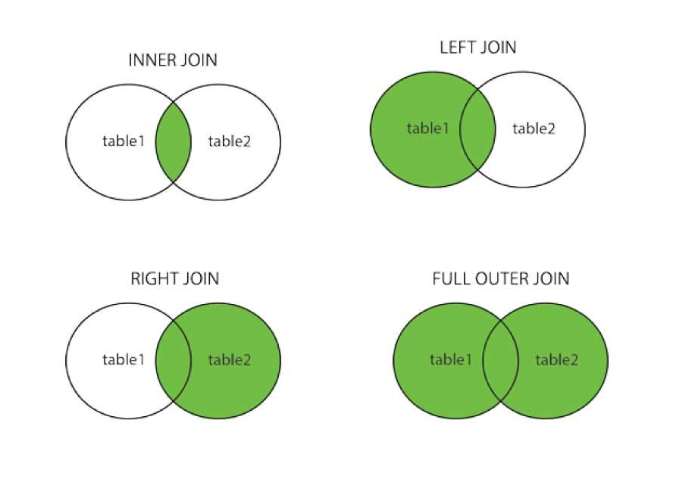

In [ ]:
# inner join   ---> common data between to tables
students.merge(reg, how='inner', on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [ ]:
# outer join  / full join
students.merge(regs, how="outer", on="student_id")

,student_id,name,partner,course_id
0,1,Kailash Harjo,23.0,1.0
1,1,Kailash Harjo,23.0,6.0
2,1,Kailash Harjo,23.0,10.0
3,1,Kailash Harjo,23.0,9.0
4,2,Esha Butala,1.0,5.0
5,3,Parveen Bhalla,3.0,3.0
6,3,Parveen Bhalla,3.0,5.0
7,4,Marlo Dugal,14.0,NaN
8,5,Kusum Bahri,6.0,NaN
9,6,Lakshmi Contractor,10.0,NaN


In [ ]:
# left join ---> left table: courses ----> right table:regs
courses.merge(regs, how='left', on="course_id")

,course_id,course_name,price,student_id
0,1,python,2499,23.0
1,1,python,2499,18.0
2,1,python,2499,1.0
3,1,python,2499,15.0
4,1,python,2499,21.0
5,1,python,2499,25.0
6,1,python,2499,12.0
7,1,python,2499,14.0
8,1,python,2499,38.0
9,2,sql,3499,19.0


In [ ]:
# right join
students.merge(regs, how="right", on="student_id")

,student_id,name,partner,course_id
0,23,Chhavi Lachman,18.0,1
1,15,Preet Sha,16.0,5
2,18,Fardeen Mahabir,13.0,6
3,23,Chhavi Lachman,18.0,4
4,16,Elias Dodiya,25.0,9
5,18,Fardeen Mahabir,13.0,1
6,1,Kailash Harjo,23.0,1
7,7,Tarun Thaker,9.0,8
8,22,Yash Sethi,21.0,3
9,15,Preet Sha,16.0,1


In [ ]:
# 1. find total revenue generated  ---> by default join is inner join
print(regs.merge(courses, how="inner", on="course_id")['price'].sum())

154247


In [ ]:
# 2. find month by month revenue
earn_nov = nov.merge(courses ,how="inner", on="course_id")['price'].sum()
earn_dec = dec.merge(courses ,how="inner", on="course_id")['price'].sum()
print(earn_nov, earn_dec)
print(earn_nov + earn_dec)

print("-------------------------------------------------------------------")
temp_df = pd.concat([nov, dec], keys=['Nov', 'Dec']).reset_index()
temp_df.merge(courses,on='course_id').groupby('level_0')['price'].sum()

# level_0 is the default name of the new column created when we do reset_index

89175 65072
154247
-------------------------------------------------------------------


,price
level_0,
Dec,65072
Nov,89175


In [ ]:
# 3. Print the registration table
# cols -> name -> course -> price

# joining multiple tables and extracting selected columns from the merged tables


regs.merge(students, on="student_id").merge(courses, on="course_id")[['name','course_name','price']]

,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


<Axes: xlabel='course_name'>

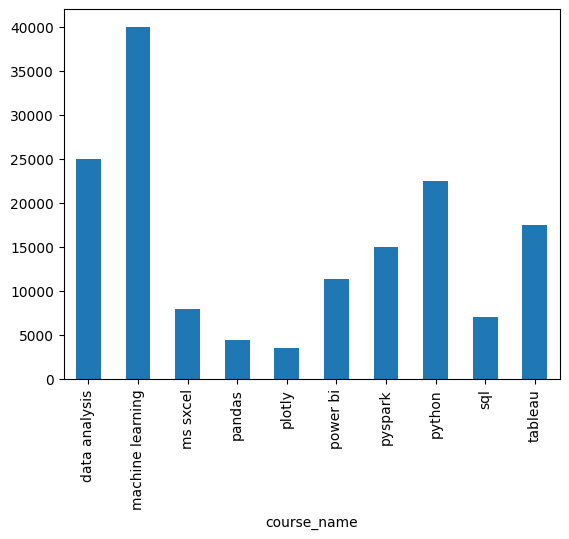

In [ ]:
# 4. Plot bar chart for revenue/course/
regs.merge(courses, on="course_id").groupby('course_name')['price'].sum().plot(kind="bar")

In [ ]:
# 5. find students who enrolled in both the months
# nov.merge(dec, on="student_id")['student_id'].unique()


# another method
common_student_id = np.intersect1d(nov['student_id'], dec['student_id'])
common_student_id

array([ 1,  3,  7, 11, 16, 17, 18, 22, 23])

In [ ]:
students[students['student_id'].isin(common_student_id)]

,student_id,name,partner
0,1,Kailash Harjo,23
2,3,Parveen Bhalla,3
6,7,Tarun Thaker,9
10,11,David Mukhopadhyay,20
15,16,Elias Dodiya,25
16,17,Yasmin Palan,7
17,18,Fardeen Mahabir,13
21,22,Yash Sethi,21
22,23,Chhavi Lachman,18


In [ ]:
# find course that got no enrollments
# courses['course_id']
regs['course_id']

course_id_list = np.setdiff1d(courses['course_id'], regs['course_id'])
courses[courses['course_id'].isin(course_id_list)]

,course_id,course_name,price
10,11,Numpy,699
11,12,C++,1299


In [ ]:
# 7. find students who did not enroll into any courses
student_id_list = np.setdiff1d(students['student_id'],regs['student_id'])
students[students['student_id'].isin(student_id_list)]

,student_id,name,partner
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8
19,20,Hanuman Hegde,11


In [ ]:
# 8. Print student name -> partner name for all enrolled students
# self join

students.merge(students, how="inner", left_on='partner', right_on='student_id')[['name_x','name_y']]

,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


In [ ]:
# 9. find top 3 students who did most number enrollments
regs.merge(students, on="student_id").groupby(['student_id','name']).count().sort_values(ascending=False).head()

TypeError: DataFrame.sort_values() missing 1 required positional argument: 'by'

In [ ]:
# 10. find top 3 students who spent most amount of money on courses
regs.merge(students, on="student_id").merge(courses, on="course_id").groupby(['student_id','name'])['price'].sum().sort_values(ascending=False).head(3)

,,price
student_id,name,
23,Chhavi Lachman,22594
14,Pranab Natarajan,15096
19,Qabeel Raman,13498


In [ ]:
# Alternate syntax for merge
# students.merge(regs)
pd.merge(students, regs, how="inner", on="student_id")

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [ ]:
# IPL Problems

# find top 3 studiums with highest sixes/match ratio
# find orange cap holder of all the seasons


NameError: name 'ipl' is not defined

In [ ]:
matches.head(2)

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN


In [ ]:
deliveries.head(2)

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,1.0,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1.0,2.0,DA Warner,S Dhawan,TS Mills,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN


In [ ]:
# find top 3 stadiums with highest sixes/match ratio
temp_df = deliveries.merge(matches, left_on="match_id", right_on="id")
six_df = temp_df[temp_df['batsman_runs'] == 6]


# stadium name --> no of sixes hit
num_sixes = six_df.groupby('venue')['venue'].count()


# no of matched in each stadium
num_matches = matches['venue'].value_counts()   # since each row is a match

In [ ]:
(num_sixes/num_matches).sort_values(ascending=False).head(3)

,0
venue,
Holkar Cricket Stadium,12.000000
De Beers Diamond Oval,11.333333
SuperSport Park,10.000000


In [ ]:
# find orange cap holder of all the seasons
temp_df.groupby(['season','batsman'])['batsman_runs'].sum().reset_index().sort_values('batsman_runs',ascending=False).drop_duplicates(subset=['season'], keep='first').sort_values('season')

,season,batsman,batsman_runs
115,2008,SE Marsh,616.0
229,2009,ML Hayden,572.0
446,2010,SR Tendulkar,618.0
540,2011,PC Valthaty,261.0
625,2017,DA Warner,641.0




---



# Multi-Index Series and Dataframes

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
# series is 1D. To fetch data from a series object in pandas , we need just a single piece of data i.e index
# dataframes is 2D. To fetch data from a datframe object in pandas, we need multiple pieced of data . i.e row, column

In [ ]:
# can we have multiple index? Let's try
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
a = pd.Series([1,2,3,4,5,6,7,8],index=index_val)
a

,0
"(cse, 2019)",1
"(cse, 2020)",2
"(cse, 2021)",3
"(cse, 2022)",4
"(ece, 2019)",5
"(ece, 2020)",6
"(ece, 2021)",7
"(ece, 2022)",8


In [ ]:
# The problem?
a['cse']

KeyError: 'cse'

In [ ]:
# The solution -> multiindex series(also known as Hierarchical Indexing)
# multiple index levels within a single index

In [ ]:
# how to create multiindex object
# 1. pd.MultiIndex.from_tuples()
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiindex = pd.MultiIndex.from_tuples(index_val)
multiindex.levels[1]
# 2. pd.MultiIndex.from_product()
pd.MultiIndex.from_product([['cse','ece'],[2019,2020,2021,2022]])

MultiIndex([('cse', 2019),
            ('cse', 2020),
            ('cse', 2021),
            ('cse', 2022),
            ('ece', 2019),
            ('ece', 2020),
            ('ece', 2021),
            ('ece', 2022)],
           )

In [ ]:
# level inside multiindex object

In [ ]:
# creating a series with multiindex object
s = pd.Series([1,2,3,4,5,6,7,8],index=multiindex)
s

# 2D object series

cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

In [ ]:
s['cse']

,0
2019,1
2020,2
2021,3
2022,4


In [ ]:
# how to fetch items from such a series
s['cse']

,0
2019,1
2020,2
2021,3
2022,4


In [ ]:
# a logical question to ask

In [ ]:
# unstack     inner most index becomes a column name  multiindex --> dataframe
temp = s.unstack()
temp

,2019,2020,2021,2022
cse,1,2,3,4
ece,5,6,7,8


In [ ]:
# stack    data frame ---> multiindex
temp.stack()

cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

In [ ]:
# multiindex is used because it can easily represent higher dimension data into 2d, for eg 10d to 2d

# Multiindex Dataframe

In [ ]:
branch_df1 = pd.DataFrame(
    [
        [1,2],
        [3,4],
        [5,6],
        [7,8],
        [9,10],
        [11,12],
        [13,14],
        [15,16],
    ],
    index = multiindex,
    columns = ['avg_package','students']
)

branch_df1

avg_package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

In [ ]:
branch_df1['students']

cse  2019     2
     2020     4
     2021     6
     2022     8
ece  2019    10
     2020    12
     2021    14
     2022    16
Name: students, dtype: int64

In [ ]:
# Are columns really different from index?

In [ ]:
# multiindex df from columns perspective
branch_df2 = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
    ],
    index = [2019,2020,2021,2022],
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)

branch_df2

delhi               mumbai         
     avg_package students avg_package students
2019           1        2           0        0
2020           3        4           0        0
2021           5        6           0        0
2022           7        8           0        0

In [ ]:
branch_df2['delhi']

,avg_package,students
2019,1,2
2020,3,4
2021,5,6
2022,7,8


In [ ]:
branch_df2['delhi']['students']

,students
2019,2
2020,4
2021,6
2022,8


In [ ]:
branch_df2.loc[2019]   # extracting rows from mutiindexed columns

delhi   avg_package    1
        students       2
mumbai  avg_package    0
        students       0
Name: 2019, dtype: int64

In [ ]:
# Multiindex df in terms of both cols and index

branch_df3 = pd.DataFrame(
    [
        [1,2,0,0],
        [3,4,0,0],
        [5,6,0,0],
        [7,8,0,0],
        [9,10,0,0],
        [11,12,0,0],
        [13,14,0,0],
        [15,16,0,0],
    ],
    index = multiindex,
    columns = pd.MultiIndex.from_product([['delhi','mumbai'],['avg_package','students']])
)

branch_df3


# now this data is 4d since to extract one number we have to provide 4 pieces of information

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

## Stacking and Unstacking

In [ ]:
branch_df1.unstack()   # inside rows become columns

avg_package                students               
           2019 2020 2021 2022     2019 2020 2021 2022
cse           1    3    5    7        2    4    6    8
ece           9   11   13   15       10   12   14   16

In [ ]:
branch_df1.unstack().unstack()      # the remaining row cse, ece is also converted to column,

# now since there is no row left, so the dataframe is now converted to a series.

avg_package  2019  cse     1
                   ece     9
             2020  cse     3
                   ece    11
             2021  cse     5
                   ece    13
             2022  cse     7
                   ece    15
students     2019  cse     2
                   ece    10
             2020  cse     4
                   ece    12
             2021  cse     6
                   ece    14
             2022  cse     8
                   ece    16
dtype: int64

In [ ]:
branch_df1.stack()

cse  2019  avg_package     1
           students        2
     2020  avg_package     3
           students        4
     2021  avg_package     5
           students        6
     2022  avg_package     7
           students        8
ece  2019  avg_package     9
           students       10
     2020  avg_package    11
           students       12
     2021  avg_package    13
           students       14
     2022  avg_package    15
           students       16
dtype: int64

In [ ]:
branch_df1.unstack().stack()      # The innerrmost row is converted to column

/tmp/ipykernel_7821/803879557.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  branch_df1.unstack().stack()      # The innerrmost row is converted to column


avg_package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

In [ ]:
branch_df1.unstack().stack().stack()

/tmp/ipykernel_7821/2994828746.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  branch_df1.unstack().stack().stack()


cse  2019  avg_package     1
           students        2
     2020  avg_package     3
           students        4
     2021  avg_package     5
           students        6
     2022  avg_package     7
           students        8
ece  2019  avg_package     9
           students       10
     2020  avg_package    11
           students       12
     2021  avg_package    13
           students       14
     2022  avg_package    15
           students       16
dtype: int64

In [ ]:
branch_df2

delhi               mumbai         
     avg_package students avg_package students
2019           1        2           0        0
2020           3        4           0        0
2021           5        6           0        0
2022           7        8           0        0

In [ ]:
branch_df2.unstack()

delhi   avg_package  2019    1
                     2020    3
                     2021    5
                     2022    7
        students     2019    2
                     2020    4
                     2021    6
                     2022    8
mumbai  avg_package  2019    0
                     2020    0
                     2021    0
                     2022    0
        students     2019    0
                     2020    0
                     2021    0
                     2022    0
dtype: int64

In [ ]:
branch_df2.stack().stack()   # 3d series

/tmp/ipykernel_7821/2649622890.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  branch_df2.stack().stack()   # 3d series


2019  avg_package  delhi     1
                   mumbai    0
      students     delhi     2
                   mumbai    0
2020  avg_package  delhi     3
                   mumbai    0
      students     delhi     4
                   mumbai    0
2021  avg_package  delhi     5
                   mumbai    0
      students     delhi     6
                   mumbai    0
2022  avg_package  delhi     7
                   mumbai    0
      students     delhi     8
                   mumbai    0
dtype: int64

In [ ]:
branch_df3.unstack().unstack()

delhi   avg_package  2019  cse     1
                           ece     9
                     2020  cse     3
                           ece    11
                     2021  cse     5
                           ece    13
                     2022  cse     7
                           ece    15
        students     2019  cse     2
                           ece    10
                     2020  cse     4
                           ece    12
                     2021  cse     6
                           ece    14
                     2022  cse     8
                           ece    16
mumbai  avg_package  2019  cse     0
                           ece     0
                     2020  cse     0
                           ece     0
                     2021  cse     0
                           ece     0
                     2022  cse     0
                           ece     0
        students     2019  cse     0
                           ece     0
                     2020  cse     0
                           ece     0
                     2021  cse     0
                           ece     0
                     2022  cse     0
                           ece     0
dtype: int64

In [ ]:
branch_df3.stack().stack()

/tmp/ipykernel_7821/4023844418.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  branch_df3.stack().stack()


cse  2019  avg_package  delhi      1
                        mumbai     0
           students     delhi      2
                        mumbai     0
     2020  avg_package  delhi      3
                        mumbai     0
           students     delhi      4
                        mumbai     0
     2021  avg_package  delhi      5
                        mumbai     0
           students     delhi      6
                        mumbai     0
     2022  avg_package  delhi      7
                        mumbai     0
           students     delhi      8
                        mumbai     0
ece  2019  avg_package  delhi      9
                        mumbai     0
           students     delhi     10
                        mumbai     0
     2020  avg_package  delhi     11
                        mumbai     0
           students     delhi     12
                        mumbai     0
     2021  avg_package  delhi     13
                        mumbai     0
           students     delhi     14
                        mumbai     0
     2022  avg_package  delhi     15
                        mumbai     0
           students     delhi     16
                        mumbai     0
dtype: int64

In [ ]:
# head and tail
branch_df3.head()
# shape
branch_df3.shape
# info
branch_df3.info()
# duplicated -> isnull
branch_df3.duplicated()
branch_df3.isnull()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 8 entries, ('cse', np.int64(2019)) to ('ece', np.int64(2022))
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   (delhi, avg_package)   8 non-null      int64
 1   (delhi, students)      8 non-null      int64
 2   (mumbai, avg_package)  8 non-null      int64
 3   (mumbai, students)     8 non-null      int64
dtypes: int64(4)
memory usage: 632.0+ bytes


delhi               mumbai         
         avg_package students avg_package students
cse 2019       False    False       False    False
    2020       False    False       False    False
    2021       False    False       False    False
    2022       False    False       False    False
ece 2019       False    False       False    False
    2020       False    False       False    False
    2021       False    False       False    False
    2022       False    False       False    False

In [ ]:
# Extracting rows single
branch_df3.loc[('cse',2022)]

delhi   avg_package    7
        students       8
mumbai  avg_package    0
        students       0
Name: (cse, 2022), dtype: int64

In [ ]:
# using iloc
branch_df3.iloc[0:5:2]

delhi               mumbai         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2021           5        6           0        0
ece 2019           9       10           0        0

In [ ]:
# Ectracting cols
branch_df3['delhi']

avg_package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

In [ ]:
# extracting multiple columns
branch_df3.iloc[:,1:3]

delhi      mumbai
         students avg_package
cse 2019        2           0
    2020        4           0
    2021        6           0
    2022        8           0
ece 2019       10           0
    2020       12           0
    2021       14           0
    2022       16           0

In [ ]:
# extracting both     --> using fancy indexing
branch_df3.iloc[[0,4],[1,2]]

,,delhi,mumbai
,,students,avg_package
cse,2019,2,0
ece,2019,10,0


In [ ]:
# sorting indexes

# here sorting in descending order
branch_df3.sort_index(ascending=False)

branch_df3.sort_index(ascending=[False, True])  # sorting the ece,cse in descending order while arranging the second indexing in ascending order



delhi               mumbai         
         avg_package students avg_package students
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0

In [ ]:
# what if i want to just sort on one level
branch_df3.sort_index(level = 0, ascending=False)

branch_df3.sort_index(level = 1, ascending=False)

delhi               mumbai         
         avg_package students avg_package students
ece 2022          15       16           0        0
cse 2022           7        8           0        0
ece 2021          13       14           0        0
cse 2021           5        6           0        0
ece 2020          11       12           0        0
cse 2020           3        4           0        0
ece 2019           9       10           0        0
cse 2019           1        2           0        0

In [ ]:
# multiindex dataframe(col) -> transpose
branch_df3.transpose()

cse                 ece               
                   2019 2020 2021 2022 2019 2020 2021 2022
delhi  avg_package    1    3    5    7    9   11   13   15
       students       2    4    6    8   10   12   14   16
mumbai avg_package    0    0    0    0    0    0    0    0
       students       0    0    0    0    0    0    0    0

In [ ]:
# swaplevel
branch_df3.swaplevel(axis=0)   # rowise indexing swap
branch_df3.swaplevel(axis=1)   # columnwise indexing swap


avg_package students avg_package students
               delhi    delhi      mumbai   mumbai
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

### Long Vs Wide Data
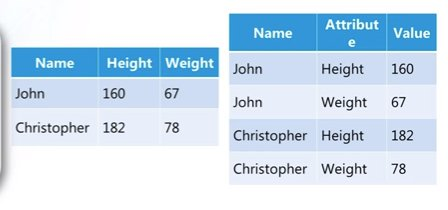

**Wide format** is where we have a single row for every data point with multiple columns to hold the values of various attributes.

**Long format** is where, for each data point we have as many rows as the number of attributes and each row contains the value of a particular attribute for a given data point.

In [ ]:
# melt -> simple example branch
# wide to long
pd.DataFrame({'cse':[120]}).melt()

,variable,value
0,cse,120


In [ ]:
# melt -> branch with year
pd.DataFrame({'cse':[120],'ece':[100],'mech':[50]})

,cse,ece,mech
0,120,100,50


In [ ]:
pd.DataFrame({'cse':[120],'ece':[100],'mech':[50]}).melt(var_name='branch',value_name='num_students')


,branch,num_students
0,cse,120
1,ece,100
2,mech,50


In [ ]:
pd.DataFrame(
    {
        'branch':['cse','ece','mech'],
        '2020':[100,150,60],
        '2021':[120,130,80],
        '2022':[150,140,70]
    }
)

,branch,2020,2021,2022
0,cse,100,120,150
1,ece,150,130,140
2,mech,60,80,70


In [ ]:
pd.DataFrame(
    {
        'branch':['cse','ece','mech'],
        '2020':[100,150,60],
        '2021':[120,130,80],
        '2022':[150,140,70]
    }
).melt(id_vars=['branch'],var_name='year',value_name='students')

,branch,year,students
0,cse,2020,100
1,ece,2020,150
2,mech,2020,60
3,cse,2021,120
4,ece,2021,130
5,mech,2021,80
6,cse,2022,150
7,ece,2022,140
8,mech,2022,70


In [ ]:
# melt -> real world example
death = pd.read_csv('/content/time_series_covid19_deaths_global.csv')
confirm = pd.read_csv('/content/time_series_covid19_confirmed_global.csv')

In [ ]:
death.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,7845,7846,7846,7846,7846,7847,7847,7849,7849,7849
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,3595,3595,3595,3595,3595,3595,3595,3595,3595,3595
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,1928,1928,1928,1930,1930,1930,1930,1930,1930,1930


In [ ]:
confirm

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.939110,67.709953,0,0,0,0,0,0,...,207310,207399,207438,207460,207493,207511,207550,207559,207616,207627
1,NaN,Albania,41.153300,20.168300,0,0,0,0,0,0,...,333749,333749,333751,333751,333776,333776,333806,333806,333811,333812
2,NaN,Algeria,28.033900,1.659600,0,0,0,0,0,0,...,271194,271198,271198,271202,271208,271217,271223,271228,271229,271229
3,NaN,Andorra,42.506300,1.521800,0,0,0,0,0,0,...,47686,47686,47686,47686,47751,47751,47751,47751,47751,47751
4,NaN,Angola,-11.202700,17.873900,0,0,0,0,0,0,...,104973,104973,104973,105095,105095,105095,105095,105095,105095,105095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,NaN,West Bank and Gaza,31.952200,35.233200,0,0,0,0,0,0,...,703228,703228,703228,703228,703228,703228,703228,703228,703228,703228
285,NaN,Winter Olympics 2022,39.904200,116.407400,0,0,0,0,0,0,...,535,535,535,535,535,535,535,535,535,535
286,NaN,Yemen,15.552727,48.516388,0,0,0,0,0,0,...,11945,11945,11945,11945,11945,11945,11945,11945,11945,11945
287,NaN,Zambia,-13.133897,27.849332,0,0,0,0,0,0,...,334021,334021,334066,334108,334196,334294,334425,334425,334629,334661


In [ ]:
death = death.melt(id_vars=['Province/State','Country/Region','Lat','Long'],var_name='date',value_name='num_deaths')
confirm = confirm.melt(id_vars=['Province/State','Country/Region','Lat','Long'],var_name='date',value_name='num_cases')


In [ ]:
death.head()

,Province/State,Country/Region,Lat,Long,date,num_deaths
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0
1,NaN,Albania,41.15330,20.168300,1/22/20,0
2,NaN,Algeria,28.03390,1.659600,1/22/20,0
3,NaN,Andorra,42.50630,1.521800,1/22/20,0
4,NaN,Angola,-11.20270,17.873900,1/22/20,0


In [ ]:
confirm.head()

,Province/State,Country/Region,Lat,Long,date,num_cases
0,NaN,Afghanistan,33.93911,67.709953,1/22/20,0
1,NaN,Albania,41.15330,20.168300,1/22/20,0
2,NaN,Algeria,28.03390,1.659600,1/22/20,0
3,NaN,Andorra,42.50630,1.521800,1/22/20,0
4,NaN,Angola,-11.20270,17.873900,1/22/20,0


In [ ]:
confirm.merge(death, on =['Province/State','Country/Region','Lat','Long','date'])[['Country/Region','date', 'num_cases','num_deaths']]

,Country/Region,date,num_cases,num_deaths
0,Afghanistan,1/22/20,0,0
1,Albania,1/22/20,0,0
2,Algeria,1/22/20,0,0
3,Andorra,1/22/20,0,0
4,Angola,1/22/20,0,0
...,...,...,...,...
311248,West Bank and Gaza,1/2/23,703228,5708
311249,Winter Olympics 2022,1/2/23,535,0
311250,Yemen,1/2/23,11945,2159
311251,Zambia,1/2/23,334661,4024




---



In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

### Pivot Table

The pivot table takes simple column-wise data as input, and groups the entries into a two-dimensional table that provides a multidimensional summarization of the data.

In [ ]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
df.groupby('sex')[['total_bill']].mean()    # average bill of male and females

# bill of non smoker males vs smoker males
df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()

/tmp/ipykernel_7238/2449739187.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sex')[['total_bill']].mean()    # average bill of male and females
/tmp/ipykernel_7238/2449739187.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()


total_bill           
smoker        Yes         No
sex                         
Male    22.284500  19.791237
Female  17.977879  18.105185

In [ ]:
df.pivot_table(index='sex', columns = 'smoker', values="total_bill")    # shoter way of the before cell code

/tmp/ipykernel_7238/3683819639.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex', columns = 'smoker', values="total_bill")    # shoter way of the before cell code


smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [ ]:
# agg function
df.pivot_table(index='sex', columns = 'smoker', values="total_bill", aggfunc = 'sum')

/tmp/ipykernel_7238/3480058239.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex', columns = 'smoker', values="total_bill", aggfunc = 'sum')


smoker,Yes,No
sex,,
Male,1337.07,1919.75
Female,593.27,977.68


In [ ]:
# multidimensional
df.pivot_table(index=['sex','smoker'], columns=['day','time'], values = 'total_bill', observed=False)

day                 Thur               Fri                Sat        Sun
time               Lunch Dinner      Lunch  Dinner     Dinner     Dinner
sex    smoker                                                           
Male   Yes     19.171000    NaN  11.386667  25.892  21.837778  26.141333
       No      18.486500    NaN        NaN  17.475  19.929063  20.403256
Female Yes     19.218571    NaN  13.260000  12.200  20.266667  16.540000
       No      15.899167  18.78  15.980000  22.750  19.003846  20.824286

In [ ]:
# multidimensional-- different agg function for different columns
df.pivot_table(index=['sex','smoker'], columns=['day','time'], values = 'total_bill', observed=False, aggfunc={'total_bill':'sum'})

day              Thur           Fri           Sat           Sun        
time            Lunch Dinner  Lunch  Dinner Lunch  Dinner Lunch  Dinner
sex    smoker                                                          
Male   Yes     191.71   0.00  34.16  129.46   0.0  589.62   0.0  392.12
       No      369.73   0.00   0.00   34.95   0.0  637.73   0.0  877.34
Female Yes     134.53   0.00  39.78   48.80   0.0  304.00   0.0   66.16
       No      381.58  18.78  15.98   22.75   0.0  247.05   0.0  291.54

In [ ]:
# margins- basically calculate totals of each column and rows (column name All)
df.pivot_table(index=['sex','smoker'], columns=['day','time'], values = 'total_bill', observed=False, aggfunc='sum', margins=True)

day               Thur           Fri           Sat            Sun           \
time             Lunch Dinner  Lunch  Dinner Lunch   Dinner Lunch   Dinner   
sex    smoker                                                                
Male   Yes      191.71   0.00  34.16  129.46   0.0   589.62   0.0   392.12   
       No       369.73   0.00   0.00   34.95   0.0   637.73   0.0   877.34   
Female Yes      134.53   0.00  39.78   48.80   0.0   304.00   0.0    66.16   
       No       381.58  18.78  15.98   22.75   0.0   247.05   0.0   291.54   
All            1077.55  18.78  89.92  235.96   NaN  1778.40   NaN  1627.16   

day                All  
time                    
sex    smoker           
Male   Yes     1337.07  
       No      1919.75  
Female Yes      593.27  
       No       977.68  
All            4827.77

In [ ]:
# plotting graphs
df = pd.read_csv('/content/expense_data.csv')

In [ ]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [ ]:
# we want to plot month by month expense of the person of each category
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    object 
 1   Account         277 non-null    object 
 2   Category        277 non-null    object 
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    object 
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    object 
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    object 
 10  Account.1       277 non-null    float64
dtypes: float64(5), object(6)
memory usage: 23.9+ KB


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[ns]
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 23.9+ KB


In [ ]:
df['Month'] = df['Date'].dt.month_name()

In [ ]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,Month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0,March
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0,March


In [ ]:
df.pivot_table(index='Month', columns='Category', values='INR',aggfunc='sum')

Category,Allowance,Apparel,Beauty,Education,Food,Gift,Household,Other,Petty cash,Salary,Self-development,Social Life,Transportation
Month,,,,,,,,,,,,,
December,11000.0,2590.0,196.0,NaN,6440.72,NaN,4800.0,1790.0,NaN,NaN,400.0,513.72,914.0
February,NaN,798.0,NaN,NaN,5579.85,NaN,2808.0,20000.0,NaN,NaN,NaN,1800.00,5078.8
January,1000.0,NaN,NaN,1400.0,9112.51,NaN,4580.0,13178.0,NaN,8000.0,NaN,200.00,2850.0
March,NaN,NaN,NaN,NaN,195.00,NaN,NaN,900.0,NaN,NaN,NaN,NaN,30.0
November,2000.0,NaN,NaN,NaN,3174.40,115.0,NaN,2000.0,3.0,NaN,NaN,NaN,331.0


In [ ]:
# fill_values  --replaces all nan values with value provided
df.pivot_table(index='Month', columns='Category', values='INR',aggfunc='sum',fill_value=0)


Category,Allowance,Apparel,Beauty,Education,Food,Gift,Household,Other,Petty cash,Salary,Self-development,Social Life,Transportation
Month,,,,,,,,,,,,,
December,11000.0,2590.0,196.0,0.0,6440.72,0.0,4800.0,1790.0,0.0,0.0,400.0,513.72,914.0
February,0.0,798.0,0.0,0.0,5579.85,0.0,2808.0,20000.0,0.0,0.0,0.0,1800.00,5078.8
January,1000.0,0.0,0.0,1400.0,9112.51,0.0,4580.0,13178.0,0.0,8000.0,0.0,200.00,2850.0
March,0.0,0.0,0.0,0.0,195.00,0.0,0.0,900.0,0.0,0.0,0.0,0.00,30.0
November,2000.0,0.0,0.0,0.0,3174.40,115.0,0.0,2000.0,3.0,0.0,0.0,0.00,331.0


<Axes: xlabel='Month'>

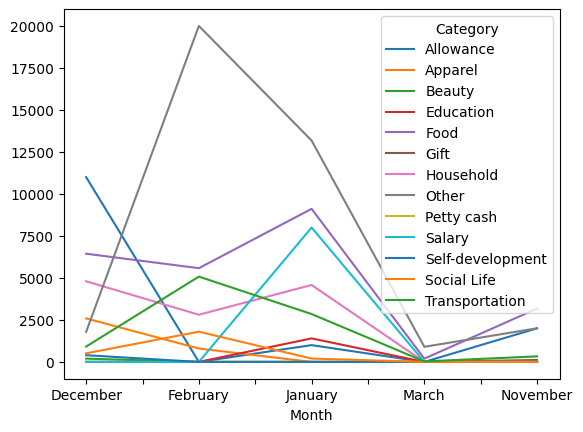

In [ ]:
# plotting graphs og pivoot table
df.pivot_table(index='Month', columns='Category', values='INR',aggfunc='sum',fill_value=0).plot()


<Axes: xlabel='Month'>

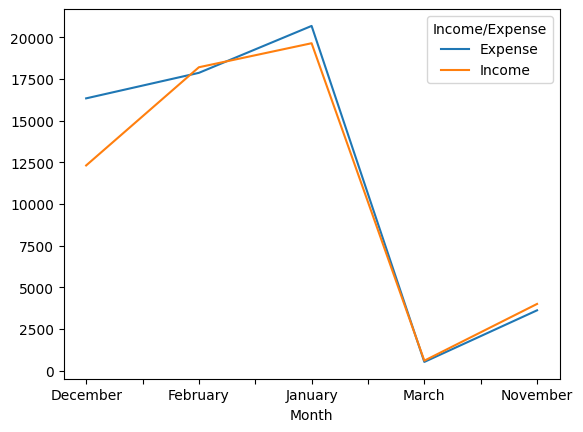

In [ ]:
df.pivot_table(index='Month', columns='Income/Expense', values='INR',aggfunc='sum',fill_value=0).plot()


# Vectorized String Operations

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# What are vectorized operations
a = np.array([1,2,3,4])
a * 4

# vectorized operation means each operation runs on each element
# in normal pyhton, vectorized ops dont works that much

array([ 4,  8, 12, 16])

In [ ]:
# problem in vectorized opertions in vanilla python  since it cant handle None values
s = ['cat','mat',None,'rat']

[i.startswith('c') for i in s]

AttributeError: 'NoneType' object has no attribute 'startswith'

In [38]:
# How pandas solves this issue?

s = pd.Series(['cat','mat',None,'rat'])
# string accessor
[s.str.startswith('c')]

# fast and optimized

[0     True
 1    False
 2     None
 3    False
 dtype: object]

In [41]:
# import titanic
df = pd.read_csv('/content/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [53]:
# common function
df['Name'].str.lower()
df['Name'].str.upper()
df['Name'].str.capitalize()
df['Name'].str.title()


# len
df['Name'][df['Name'].str.len() == 82]


# strip -- remove leading and trailing spaces
df['Name'].str.strip()


# split
df['Name'].str.split(',')


,Name
0,"[Braund, Mr. Owen Harris]"
1,"[Cumings, Mrs. John Bradley (Florence Briggs ..."
2,"[Heikkinen, Miss. Laina]"
3,"[Futrelle, Mrs. Jacques Heath (Lily May Peel)]"
4,"[Allen, Mr. William Henry]"
...,...
886,"[Montvila, Rev. Juozas]"
887,"[Graham, Miss. Margaret Edith]"
888,"[Johnston, Miss. Catherine Helen ""Carrie""]"
889,"[Behr, Mr. Karl Howell]"


In [56]:
# splt -> get      --extract surname from the above table
df['lastname'] = df['Name'].str.split(',').str.get(0)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen


In [61]:
df['Name'].str.split(",").str.get(1).str.strip().str.split(" ")

,Name
0,"[Mr., Owen, Harris]"
1,"[Mrs., John, Bradley, (Florence, Briggs, Thayer)]"
2,"[Miss., Laina]"
3,"[Mrs., Jacques, Heath, (Lily, May, Peel)]"
4,"[Mr., William, Henry]"
...,...
886,"[Rev., Juozas]"
887,"[Miss., Margaret, Edith]"
888,"[Miss., Catherine, Helen, ""Carrie""]"
889,"[Mr., Karl, Howell]"


In [65]:
# split just on the basis of first space in above
# n
# expand
df[['title', 'First_Name']] = df['Name'].str.split(",").str.get(1).str.strip().str.split(" ", n=1, expand=True)


In [66]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname,title,First_Name
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr.,Owen Harris
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs.,John Bradley (Florence Briggs Thayer)
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss.,Laina
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs.,Jacques Heath (Lily May Peel)
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr.,William Henry


In [67]:
# if we want how many of people are mr, mrs or master
df['title'].value_counts()

,count
title,
Mr.,517
Miss.,182
Mrs.,125
Master.,40
Dr.,7
Rev.,6
Col.,2
Mlle.,2
Major.,2


In [70]:
# replace
# Ms. with Miss.
# and Mlle. with Miss.
df['title'] = df['title'].str.replace('Ms.','Miss.')
df['title'] = df['title'].str.replace('Mlle.','Miss.')


In [71]:

df['title'].value_counts()

,count
title,
Mr.,517
Miss.,185
Mrs.,125
Master.,40
Dr.,7
Rev.,6
Major.,2
Col.,2
Don.,1


In [75]:
# filtering
# startswith / endswith
df[df['First_Name'].str.startswith('A')]


# isdigit / isalpha
df[df['First_Name'].str.isdigit()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname,title,First_Name


In [81]:
# applying regex
# contains

# search john -> both upper and lower case
df[df['First_Name'].str.contains('john',case=False)]

# find lastnames with start and end with vowel
df[df['lastname'].str.contains('^[aeiouAEIOU].+[aeiouAEIOU]$')]

# find lastnames with start and end with consonant
df[df['lastname'].str.contains('^[^aeiouAEIOU].+[^aeiouAEIOU]$')]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,lastname,title,First_Name
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr.,Owen Harris
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs.,John Bradley (Florence Briggs Thayer)
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss.,Laina
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,Moran,Mr.,James
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,McCarthy,Mr.,Timothy J
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S,Sutehall,Mr.,Henry Jr
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Graham,Miss.,Margaret Edith
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,Johnston,Miss.,"Catherine Helen ""Carrie"""
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Behr,Mr.,Karl Howell


In [84]:
# slicing
# fetch first four chars of each name

df['Name'].str[:4]

,Name
0,Brau
1,Cumi
2,Heik
3,Futr
4,Alle
...,...
886,Mont
887,Grah
888,John
889,Behr


# Vectorized DateTime Operations


### Timestamp Object

Time stamps reference particular moments in time (e.g., Oct 24th, 2022 at 7:00pm)

In [91]:
# creating a timestamp
# make a habit year -month -day

pd.Timestamp('2026/4/25')
pd.Timestamp('2026-4-25')
pd.Timestamp('2026, 4, 25')  # need to give space after comma to make it work
pd.Timestamp('2026 4 25')



Timestamp('2026-04-25 00:00:00')

In [92]:
pd.Timestamp('2026')    # automatically assigns 1 jan


Timestamp('2026-01-01 00:00:00')

In [96]:
pd.Timestamp('25 april 2026')
pd.Timestamp('25th april 2026')
pd.Timestamp('25rd april 2026')

Timestamp('2026-04-25 00:00:00')

In [108]:
pd.Timestamp('2016, 4, 5, 4:23PM')
pd.Timestamp('2016/4/5/4:23PM')

pd.Timestamp('25th April 2026 4:24PM')


Timestamp('2026-04-25 16:24:00')

In [113]:
# using datetime.datetime object in pyhton
import datetime as dt

dt.datetime(2026,4,25,4,25)
pd.Timestamp(dt.datetime(2026,4,25,4,27))
x = pd.Timestamp(dt.datetime(2026,4,25,4,27))
x

Timestamp('2026-04-25 04:27:00')

In [119]:
# fetching attributes
x.year
x.month
x.day
x.hour
x.minute
x.second

0

## Why did pandas create a timestamp object inspite of a datetime object being present in python

- syntax wise datetime is very convenient
- But the performance takes a hit while working with huge data. List vs Numpy Array
- The weaknesses of Python's datetime format inspired the NumPy team to add a set of native time series data type to NumPy.
- The datetime64 dtype encodes dates as 64-bit integers, and thus allows arrays of dates to be represented very compactly.

In [120]:
import numpy as np
date = np.array('2015-07-04', dtype = np.datetime64)
date

array('2015-07-04', dtype='datetime64[D]')

In [121]:
# numpy datetiem object can perform vector operations on it
date + np.arange(12)

array(['2015-07-04', '2015-07-05', '2015-07-06', '2015-07-07',
       '2015-07-08', '2015-07-09', '2015-07-10', '2015-07-11',
       '2015-07-12', '2015-07-13', '2015-07-14', '2015-07-15'],
      dtype='datetime64[D]')

- Because of the uniform type in NumPy datetime64 arrays, this type of operation can be accomplished much more quickly than if we were working directly with Python's datetime objects, especially as arrays get large

- Pandas Timestamp object combines the ease-of-use of python datetime with the efficient storage and vectorized interface of numpy.datetime64

- From a group of these Timestamp objects, Pandas can construct a DatetimeIndex that can be used to index data in a Series or DataFrame

### pandas timestamp internally uses numpy's datetime64

# DatetimeIndex Object
 - a collection of pandas timestamp
```
 - single timestamp = Timestamp
 - multiple timestamps = DateTimeIndex
```

In [126]:
# from strings
print(pd.DatetimeIndex(['2023/1/1','2022/1/1','2021/1/1']))
# DatetimeIndex is a collection of timestamps. it can be proved by fetching first index from the datetimeIndex
pd.DatetimeIndex(['2023/1/1','2022/1/1','2021/1/1'])[0]


DatetimeIndex(['2023-01-01', '2022-01-01', '2021-01-01'], dtype='datetime64[ns]', freq=None)


Timestamp('2023-01-01 00:00:00')

In [127]:
# using python datetime object
pd.DatetimeIndex([dt.datetime(2023,1,1),dt.datetime(2022,1,1),dt.datetime(2021,1,1)])

DatetimeIndex(['2023-01-01', '2022-01-01', '2021-01-01'], dtype='datetime64[ns]', freq=None)

In [128]:
# using pd.timestamps
dt_index = pd.DatetimeIndex([pd.Timestamp(2023,1,1),pd.Timestamp(2022,1,1),pd.Timestamp(2021,1,1)])

In [129]:
# using datatimeindex as series index

pd.Series([1,2,3],index=dt_index)

,0
2023-01-01,1
2022-01-01,2
2021-01-01,3


### date_range function

In [133]:
# generate daily dates in a given range

# default value of freq id D
pd.date_range(start='2023/1/5',end='2023/2/28',freq='D')


pd.date_range(start='2023/1/5',end='2023/2/28',freq='3D')

DatetimeIndex(['2023-01-05', '2023-01-08', '2023-01-11', '2023-01-14',
               '2023-01-17', '2023-01-20', '2023-01-23', '2023-01-26',
               '2023-01-29', '2023-02-01', '2023-02-04', '2023-02-07',
               '2023-02-10', '2023-02-13', '2023-02-16', '2023-02-19',
               '2023-02-22', '2023-02-25', '2023-02-28'],
              dtype='datetime64[ns]', freq='3D')

In [134]:
# alternate days in a given range
pd.date_range(start='2023/1/5',end='2023/2/28',freq='2D')

DatetimeIndex(['2023-01-05', '2023-01-07', '2023-01-09', '2023-01-11',
               '2023-01-13', '2023-01-15', '2023-01-17', '2023-01-19',
               '2023-01-21', '2023-01-23', '2023-01-25', '2023-01-27',
               '2023-01-29', '2023-01-31', '2023-02-02', '2023-02-04',
               '2023-02-06', '2023-02-08', '2023-02-10', '2023-02-12',
               '2023-02-14', '2023-02-16', '2023-02-18', '2023-02-20',
               '2023-02-22', '2023-02-24', '2023-02-26', '2023-02-28'],
              dtype='datetime64[ns]', freq='2D')

In [135]:
# B -> business days
pd.date_range(start='2023/1/5',end='2023/2/28',freq='B')

DatetimeIndex(['2023-01-05', '2023-01-06', '2023-01-09', '2023-01-10',
               '2023-01-11', '2023-01-12', '2023-01-13', '2023-01-16',
               '2023-01-17', '2023-01-18', '2023-01-19', '2023-01-20',
               '2023-01-23', '2023-01-24', '2023-01-25', '2023-01-26',
               '2023-01-27', '2023-01-30', '2023-01-31', '2023-02-01',
               '2023-02-02', '2023-02-03', '2023-02-06', '2023-02-07',
               '2023-02-08', '2023-02-09', '2023-02-10', '2023-02-13',
               '2023-02-14', '2023-02-15', '2023-02-16', '2023-02-17',
               '2023-02-20', '2023-02-21', '2023-02-22', '2023-02-23',
               '2023-02-24', '2023-02-27', '2023-02-28'],
              dtype='datetime64[ns]', freq='B')

In [137]:
# W -> one week per day
pd.date_range(start='2023/1/5',end='2023/2/28',freq='W')

pd.date_range(start='2023/1/5',end='2023/2/28',freq='W-THU')


DatetimeIndex(['2023-01-05', '2023-01-12', '2023-01-19', '2023-01-26',
               '2023-02-02', '2023-02-09', '2023-02-16', '2023-02-23'],
              dtype='datetime64[ns]', freq='W-THU')

In [141]:
# h -> Hourly data(factor)
pd.date_range(start='2023/1/5',end='2023/2/28',freq='6h')   # every 6 hours

DatetimeIndex(['2023-01-05 00:00:00', '2023-01-05 06:00:00',
               '2023-01-05 12:00:00', '2023-01-05 18:00:00',
               '2023-01-06 00:00:00', '2023-01-06 06:00:00',
               '2023-01-06 12:00:00', '2023-01-06 18:00:00',
               '2023-01-07 00:00:00', '2023-01-07 06:00:00',
               ...
               '2023-02-25 18:00:00', '2023-02-26 00:00:00',
               '2023-02-26 06:00:00', '2023-02-26 12:00:00',
               '2023-02-26 18:00:00', '2023-02-27 00:00:00',
               '2023-02-27 06:00:00', '2023-02-27 12:00:00',
               '2023-02-27 18:00:00', '2023-02-28 00:00:00'],
              dtype='datetime64[ns]', length=217, freq='6h')

In [142]:
# ME -> Month end
pd.date_range(start='2023/1/5',end='2023/2/28',freq='ME')

DatetimeIndex(['2023-01-31', '2023-02-28'], dtype='datetime64[ns]', freq='ME')

In [143]:
# MS -> Month start
pd.date_range(start='2023/1/5',end='2023/2/28',freq='MS')

DatetimeIndex(['2023-02-01'], dtype='datetime64[ns]', freq='MS')

In [145]:
# YE -> Year end
pd.date_range(start='2023/1/5',end='2030/2/28',freq='YE')

DatetimeIndex(['2023-12-31', '2024-12-31', '2025-12-31', '2026-12-31',
               '2027-12-31', '2028-12-31', '2029-12-31'],
              dtype='datetime64[ns]', freq='YE-DEC')

In [146]:
# YS -> Year end
pd.date_range(start='2023/1/5',end='2030/2/28',freq='YS')

DatetimeIndex(['2024-01-01', '2025-01-01', '2026-01-01', '2027-01-01',
               '2028-01-01', '2029-01-01', '2030-01-01'],
              dtype='datetime64[ns]', freq='YS-JAN')

In [148]:
# using periods(number of results)    --no need to specify end
pd.date_range(start='2023/1/5',periods=25,freq='ME')

DatetimeIndex(['2023-01-31', '2023-02-28', '2023-03-31', '2023-04-30',
               '2023-05-31', '2023-06-30', '2023-07-31', '2023-08-31',
               '2023-09-30', '2023-10-31', '2023-11-30', '2023-12-31',
               '2024-01-31', '2024-02-29', '2024-03-31', '2024-04-30',
               '2024-05-31', '2024-06-30', '2024-07-31', '2024-08-31',
               '2024-09-30', '2024-10-31', '2024-11-30', '2024-12-31',
               '2025-01-31'],
              dtype='datetime64[ns]', freq='ME')

In [150]:
# using periods(number of results)
pd.date_range(start='2023/1/5',periods=25,freq='h')

DatetimeIndex(['2023-01-05 00:00:00', '2023-01-05 01:00:00',
               '2023-01-05 02:00:00', '2023-01-05 03:00:00',
               '2023-01-05 04:00:00', '2023-01-05 05:00:00',
               '2023-01-05 06:00:00', '2023-01-05 07:00:00',
               '2023-01-05 08:00:00', '2023-01-05 09:00:00',
               '2023-01-05 10:00:00', '2023-01-05 11:00:00',
               '2023-01-05 12:00:00', '2023-01-05 13:00:00',
               '2023-01-05 14:00:00', '2023-01-05 15:00:00',
               '2023-01-05 16:00:00', '2023-01-05 17:00:00',
               '2023-01-05 18:00:00', '2023-01-05 19:00:00',
               '2023-01-05 20:00:00', '2023-01-05 21:00:00',
               '2023-01-05 22:00:00', '2023-01-05 23:00:00',
               '2023-01-06 00:00:00'],
              dtype='datetime64[ns]', freq='h')

### to_datetime function

converts an existing objects to pandas timestamp/datetimeindex object

In [157]:
# example

s = pd.Series(['2023/1/1','2022/12/1','2021/1/1'])
# dt - accessor for datetime
pd.to_datetime(s).dt.month_name()

,0
0,January
1,December
2,January


In [158]:
# with errors
s = pd.Series(['2023/1/1','2022/1/1','2021/130/1'])
pd.to_datetime(s,errors='coerce').dt.month_name()

,0
0,January
1,January
2,NaN


In [159]:
df = pd.read_csv('/content/expense_data.csv')
df.shape

(277, 11)

In [160]:
df.head()

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,3/1/2022 18:56,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,3/1/2022 18:22,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0


In [163]:
df['Date'] = pd.to_datetime(df['Date'])

In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[ns]
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 23.9+ KB


### dt accessor

Accessor object for datetimelike properties of the Series values.

In [168]:
df[df['Date'].dt.is_quarter_start]

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
151,2022-01-01 21:46:00,CUB - online payment,Food,NaN,Snacks,85.0,Expense,NaN,85.0,INR,85.0
152,2022-01-01 21:45:00,CUB - online payment,Allowance,NaN,From dad,1000.0,Income,NaN,1000.0,INR,1000.0


In [169]:
df[df['Date'].dt.is_month_start]

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0
3,2022-03-01 18:56:00,CUB - online payment,Transportation,NaN,Metro,30.0,Expense,NaN,30.0,INR,30.0
4,2022-03-01 18:22:00,CUB - online payment,Food,NaN,Snacks,67.0,Expense,NaN,67.0,INR,67.0
5,2022-03-01 18:22:00,CUB - online payment,Other,NaN,From vicky,100.0,Income,NaN,100.0,INR,100.0
6,2022-03-01 18:21:00,CUB - online payment,Other,NaN,From dad,500.0,Income,NaN,500.0,INR,500.0
151,2022-01-01 21:46:00,CUB - online payment,Food,NaN,Snacks,85.0,Expense,NaN,85.0,INR,85.0
152,2022-01-01 21:45:00,CUB - online payment,Allowance,NaN,From dad,1000.0,Income,NaN,1000.0,INR,1000.0
240,2021-12-01 19:57:00,CUB - online payment,Beauty,NaN,Showergel,196.0,Expense,NaN,196.0,INR,196.0
241,2021-12-01 14:00:00,CUB - online payment,Food,NaN,Lunch with company,160.0,Expense,NaN,160.0,INR,160.0


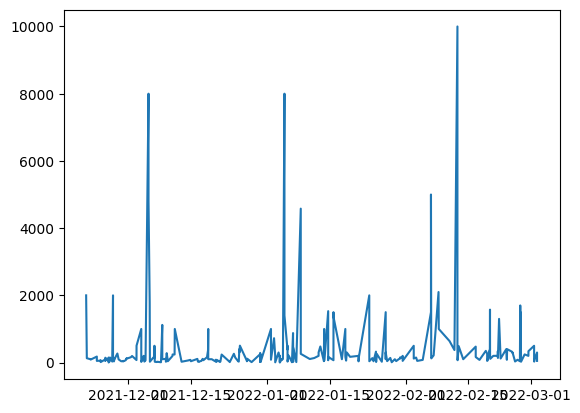

In [170]:
# plot graph
import matplotlib.pyplot as plt
plt.plot(df['Date'],df['INR'])

<Axes: xlabel='Day_Name'>

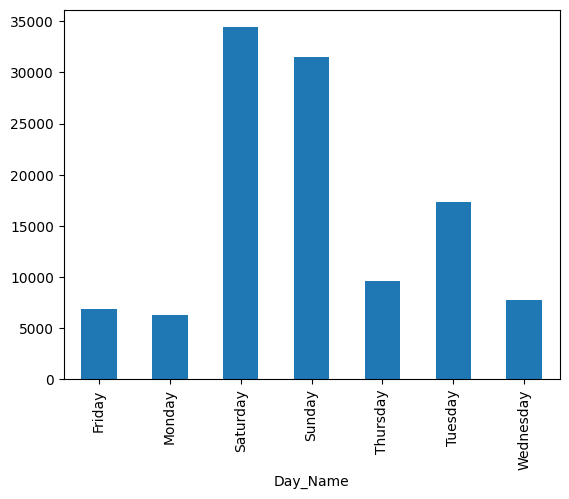

In [178]:
# day name wise bar chart/month wise bar chart
# for eg . ehich day he spends the most

df['Day_Name'] = df['Date'].dt.day_name()
df.head()


df.groupby('Day_Name')['INR'].sum().plot(kind='bar')

<Axes: xlabel='Month_Name'>

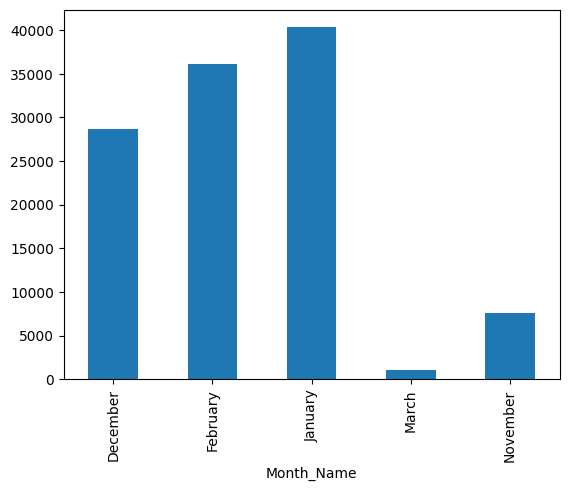

In [188]:
# monthwise total spendings bar chart
df['Month_Name'] = df['Date'].dt.month_name()
df.head()

df.groupby('Month_Name')['INR'].sum().plot(kind='bar')

In [193]:
# tell how much he spends on month end

df[df['Date'].dt.is_month_end].groupby('Month_Name')['INR'].sum()

,INR
Month_Name,
February,539.15
January,403.00
November,313.00
